In [10]:
pip install xgboost

  Using cached xgboost-3.1.3-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.1.3-py3-none-win_amd64.whl (72.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kstest, anderson


#Grab data and put numerical vals in one table
#################################################################################################################
dataset_as_given = pd.read_csv(r"d:\Desktop\Practice Python\21.gym_members_exercise_tracking.csv")
#print(dataset_as_given)

# Get column names
column_names = dataset_as_given.columns
#print(column_names)

desired = ["Age", "Weight (kg)", "Height (m)", "Max_BPM", "Avg_BPM", "Resting_BPM", 
           "Session_Duration (hours)", "Calories_Burned", "Fat_Percentage", "Water_Intake (liters)", "Workout_Frequency (days/week)", "Experience_Level", "BMI"]

dataset_as_given_numeric = dataset_as_given[desired]



#Get Rid of Outliers
#################################################################################################################

# Copy the dataset so you keep the original intact
cleaned_df = dataset_as_given.copy()

# Select numeric columns
numeric_cols = cleaned_df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]



print("Original rows:", dataset_as_given.shape[0])
print("Cleaned rows:", cleaned_df.shape[0])
print("Rows removed:", dataset_as_given.shape[0] - cleaned_df.shape[0])


#################################################################################################################

encoded_df = cleaned_df.copy()

encoded_df['Gender'] = encoded_df['Gender'].map({
    'Male': 1,
    'Female': 0
})

workout_dummies = pd.get_dummies(encoded_df['Workout_Type'], prefix='Workout', drop_first=True)
encoded_df = pd.concat([encoded_df.drop(columns=['Workout_Type']), workout_dummies], axis=1)




Original rows: 973
Cleaned rows: 931
Rows removed: 42


In [2]:
# ============================================================
#   TRAIN/TEST SPLIT + SCALING
#   This prepares your data for any ML model
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Define X (features) and y (target)
# ------------------------------------------------------------
# Gender must already be encoded as 0/1 in encoded_df
X = encoded_df.drop(columns=['Gender'])
y = encoded_df['Gender']

# ------------------------------------------------------------
# 2. Train/Test Split
# ------------------------------------------------------------
# test_size=0.2 means 20% of data is held out for testing
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 3. Scale the numeric features
# ------------------------------------------------------------
# Scaling helps models like Logistic Regression, SVM, KNN, Neural Networks
# Tree-based models (Random Forest, XGBoost) do NOT require scaling,
# but scaling does not harm them.
scaler = StandardScaler()

# Fit on training data ONLY, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 4. Optional: Print shapes to confirm everything looks right
# ------------------------------------------------------------
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nScaled versions created: X_train_scaled, X_test_scaled")


X_train shape: (744, 16)
X_test shape: (187, 16)
y_train shape: (744,)
y_test shape: (187,)

Scaled versions created: X_train_scaled, X_test_scaled


K-Nearest Neighbor (KNN) Algorithm is a supervised machine learning algorithm that is generally used for classification but can also be used for regression tasks<br><br>

The algorithm works by finding the "K" closest data points (neighbors) to a given input and makes a prediction based on the majority class (for classification) ir the average value (for regression)<br><br>

This type of algorithm makes no assumption about the underlaying data distribution it makes it a non-parametric and instance based learning method<br><br>

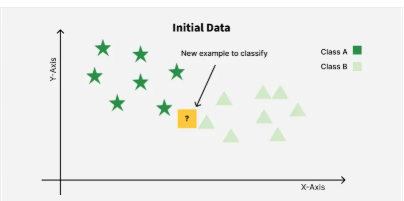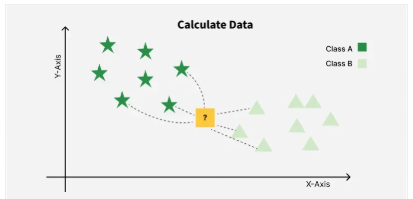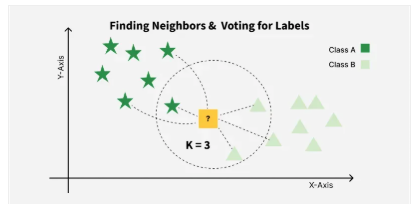<br><br>

K-Nearest neighbors is also called a lazy learner algorithm because it does not learn from the training set immediately - instead, it stores the entire dataset and performs computations only at the time of classification<br><br>

As an example - let us consider 2 features which will be called Category 1 and Category 2<br><br>

- KNN assigns the category based on the majority of nearby points -> the image below shows how KNN predicts the category of a new data point based on its closest neighbours<br><br>

- The green points represent Category 1 while the red points represent Category 2<br><br>

- The new datapoint checks its closest neighbours (circled points)<br><br>

- Since the majority of its closest neighbours are red points (belonging to Category 2) -> the model predicts that the new data point belongs to Category 2 as well<br><br>

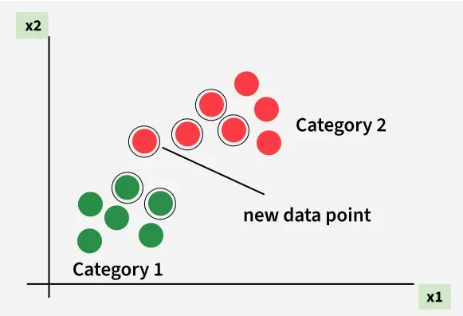<br><br>

The discussed type of model uses proximity and majority voting to make predictions<br><br>

The 'K' in K Nearest Neighbour is just a number that tells the algorithm how many nearby points or neighbours to look at when it makes a decision<br><br>

Example: We are trying to put a specific fruit in a category -> therefor we compare its shape and size to that of fruits that are already familiar to us<br>
- If K = 3 -> the algorithm looks at the closest 3 fruits to the new one<br>
- If 2 of those 3 fruits are apples and 1 is a banana, the algorithm says the new fruit is an apple because most of its neighbours are apples<br><br>

How is the value of K for the KNN Algorithm chosen?<br><br>

- The value of K in the algorithm decides how many neighbours the algorithm looks at when making a prediction<br><br>

- Choosing the correct K is important for good results <br><br>

- If the data contains lots of noise or outliers, using a larger K can make the predictions more stable<br><br>

- But if K is too large, the model can become too simple and miss important patterns and this is called underfitting<br><br>

- K should be picked carefully based on the existing data<br><br>

What are some possible Statistical Methods for Selecting K?<br><br>

- Cross-Validation -> this is a good way to find the best value of K using k-fold validation. For this to happen, the dataset will be devided into K parts, then the model will be trained on some of the parts and tested on the remainder of the parts. The process repeats itself for all of the parts. The K value that gives the highest value for accuracy during the tests - is normally the best k value to use<br><br>

- Elbow Methods -> for this method, a graph is drawn that shows the error rate or accuracy for various K values. As K increases, the error usually drops at first, and after a certain point the error stops decresing quickly. The point where the curve changes direction and looks like an 'elbow' is usually the best choice for K this method offers<br><br>

- Odd Values for K -> using an odd number for K is a good idea for classification problems. This method avoids ties when deciding which class is the mosr common among the neighbours<br><br>

Distance Metrics are used in the KNN algorithm. These can include:<br><br>

1. Euclidean Distance -> which is defined as a straight line distance between two points in a plane or space. This is the shortest path that can be walked from Point A directly to Point B<br><br>

2. Manhattan Distance -> this is the total distance you could walk from Point A to Point B if you could only walk along horizontal and vertical lines like a grid or city streets. This type of distance is also called the 'taxicab distance' because a taxi can only drive along the grid-like streets of a city<br><br>

3. Minkowski Distance -> this type of distance is like a familty of distances which includes both Euclidean and Manhattan distances as special cases. For the Minkowski distance, its formula is flexible and can represent either Euclidean or Manhattan distance depending on the inputted values<br><br>

How does the K-Nearest Neighbours algortihm work?<br><br>

The discussed algorithm operates on the principle of similarity where it predics the label or value of a new data point by considering the labels or values of its K nearest neighbours in the training dataset<br><br>

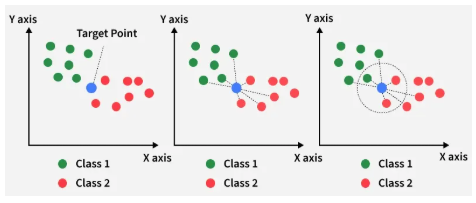<br><br>

Step 1: Select the optimal value for K<br>
K represents the number of nearest neighbours that needs to be considered while making predictions<br><br>

Step 2: Calculating the distance<br>
To measure the similarity between target and training data point - Euclidean distance is widely used. The distance is calculated between datapoints in the dataset and target point<br><br>

Step 3: Finding nearest neighbours<br>
The K data points with the smallest distance to the targer point are nearest neighbours<br><br>

Step 4: Voting for Classification or Taking Average for Regression<br>
-When you want to classify a data point into a category like Spam VS Not Spam, the KNN algorithm looks at the closest K points in the dataset. These closest points are called neighbours. The algorithm them looks at which category the neighbours belong to and picks the one that appears the most. This is called majority voting<br> 
-In regression, the algorithm still looks for the K closest points, but instead of voting for a class in classification, it takes the average of values of those K neighbours. This average is the predicted value for the new point for the algorithm<br><br>

Applications of KNN include:<br><br>

- Reccomandation Systems -> to suggest items like movies or products by finding users with similar preferences<br><br>

- Spam Detection -> to identify spam emails by comparing new emails to known spam and non-spam examples<br><br>

- Customer Segmenatation -> to group customers by comparing their shopping behaviours to other customers<br><br>

- Speech Recognition -> to match spoken words to known patterns to convert them into text<br><br>

Advantages of KNN include:<br><br>

- That the model is simple to use -> easy to understand and implement<br><br>

- There are no training steps -> there is no need to train as it just stores the data and uses it during prediction<br><br>

- It uses few parameters -> it only needs to set the number of neighbours (K) and a distance method<br><br>

- Versatility -> works for both classification and regression problems<br><br>

Disadvantages of the model include:<br><br>

- It is slow with large data -> needs to compare every point during prediction<br><br>

- Struggles with many features -> accuracy drops when data has too many features<br><br>

- Can overfit -> It can overfit especially when the data is high-dimensional and has not been cleaned<br><br>

https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/<br><br>

Machine Learning is a branch of Artificial Intelligence that focuses on developing models and algorithms that let computers learn from data without being explecitly programmed for every task. In simple words, Machine Learning teaches system to think and understand like humans by learning from data.<br><br>

Machine Learning is divided into 3 main types:<br><br>

- Supervised Laerning -> meaning that the model trains on labeled data to predict or classify unseen data<br><br>

- Unsupervised Learning -> finds patterns or groups in unlabeled data, like clustering or dimensionality reduction<br><br>

- Reinforcement Learning -> learns through trial and error to maximize reqards, ideal for decision-making tasks<br><br>

Note: The following two additional types of machine learning are not part of the original 3 core types of machine learning but they have become incresingly important in real-world applications, especially in deep learning:<br><br>

- Self-Supervised Machine Learning -> this type of machine learning is often considered to be a subset of unsupervised learning, but it has grown into its own field due to its success in training large-scale models. It generates its own labels from the data, without any manual lableling<br><br>

- Semi-Supervised Machine Learning -> this approach combines a small amount of labeled data with a large amount of unlabeled data. This method is useful when labeling data is time-consuming or expensive<br><br>

https://www.geeksforgeeks.org/machine-learning/machine-learning/<br><br>

Machine Learning Models should learn useful patterns from training data. When a model learn too much or too little, overfitting and underfitting happen.<br><br>

Underfitting -> means that the model is too simple and does not cover all the real patterns in the data<br><br>

Overfitting -> means that the model learns not just the underlying pattern, but also noise or random quircks in the training data -> the model ends up memorizing the data<br><br>

A good model -> finds the good spot that is complex enough to learn real patterns, but not so complex that it memorizes moise<br><br>

What is Underfitting?<br><br>

Underfitting happens when the model fails to learn important patterns. It performs poorly on both training and testing data. Underfitting can happen due to:<br><br>

- The model being too simple<br><br>

- Very high regularization<br><br>

- Features are weak or missing<br><br>

- Not enough training<br><br>

- High bias<br><br>

Bias: it is like assuming that all birds can only be small and fly, so the model fails to recognize big birds like ostrices or penguins that can not fly and become biased in its predictions -> bias can be when you make an assumtion about the data - or in this case the machine learning model makes an assumption about the data that because it does not see the full picture of things -> which can happen if one category that is included in the dataset appears a lot more than the other etc.<br><br>

Bias-Variance Inside Underfitting<br><br>

Underfitting mainly occurs to high bias:<br><br>

- Meaning that due to high bias, the model makes strong assumptions<br><br>

- It also ignores patterns<br><br>

- It learns an overly simple representation of the dataset<br><br>

- Variance is low because the model gives similar outputs even if the data changes<br><br>

Underfitting = High Bias + Low Variance<br><br>

What is Overfitting?<br><br>

Overfitting is mainly caused by high variance -> high variance means that the model reacts too strongly to the training data, learning noise as patterns. The dataset can also contain low bias because the model is extremely flexible<br><br>

Overfitting = Low Bias + High Variance<br><br>

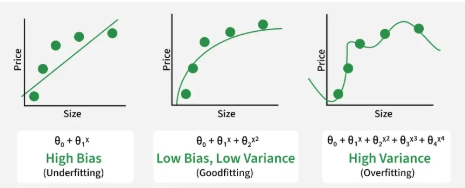<br><br>

As seen in the image:<br><br>

- Underfitting -> is represented by a straight line that is trying to fit a curved dataset but it can not capture the pattern of the data, leading to poor performance on both training and test sets<br><br>

- Overfitting -> represented by a squggly curve passing through all training points, failing to generalize -> the model would perform well on the training data but poorly on the test data<br><br>

- Appropriate Fittng -> represented by the line that follows the data trend without overcomplicating capturing the true patterns of the dataset<br><br> 

Bias-Variance Tradeoff<br><br>

The relationship between bias and variance is often referred to as the bias-variance tradeoff, which highlights the need for balance between the 2<br>
Increasing model complexity reduces bias but increases variance (risk of overfitting)<br>
Simplifing the model reduces variance but increases bias (risk of underfitting)<br><br>

The goal is to find an optimal balance where both bias and variance are minimized, resulting in good generalization performance<br><br>

Imagine predicting house prices based on size. You plot the data and try and draw a curve that represents the trend. How well this curve fits depends on the complexity of the model<br><br>

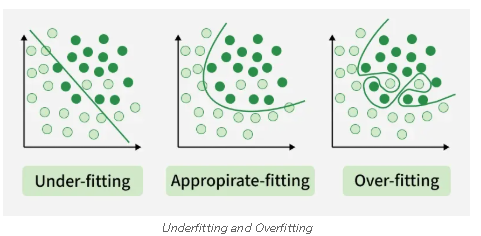<br><br>

Underfitting (High Bias) -> a model that is too simple is produced (like a straight line for curved data) -> which misses key patterns and performs poorly on both training and testing data<br><br>

Overfitting (High Variance) -> a model that is too compled is produced (like a high degree polynomial) -> which learns noise, fits training data too closely, and performs poorly on new data<br><br>

Ideal Fit (Balanced) -> a model that is moderately compled is produced -> which captures the main trend without following noise, giving good performance on both training and testing data<br><br>

How are Overfitting and Underfitting addressed?<br><br>

Techniques to Reduce Underfitting<br>
- Use a more complex model<br>
- Add new features amd perform feature engineering<br>
- Reduce Regularization<br>
- Train for more epochs<br>
- Scale features properly<br><br>

Techniques to reduce Overfitting<br>
- Collect more training data<br>
- Reduce model complexity<br>
- Use Regularization (L1/L2)<br>
- Apply dropout (for neural networks)<br>
- Use early stopping<br>
- Clean noisy data<br><br>

https://www.geeksforgeeks.org/machine-learning/underfitting-and-overfitting-in-machine-learning/<br><br>

What are Epochs in Machine Learning?<br><br>

When it comes to Machine Learning, the training data is almost nerver processed in a single pass. Instead, the data is shown to the model multiple times so it can gradually refine its parameters. An epoch referes to 1 complete pass over the entire training set. For instance, with a dataset of 1 million images, one epoch means that the model has seen each image once. <br><br>

Within one epoch, training happens in batches. Each batch updates the model's internal parameters - its weights and biases - based on computed gradients. The first epoch mainly helps the model get oriented, while subsequent epochs allow it to capture more stable and meaningful patterns. <br><br>

Every additional epoch given the network another opportunity to fine-tune its weights, improve accuracy and reduce error. But more is not always better in this case as after a point, the model may stop learning generalizable patterns and begin overfitting by memorizing noise in the data. This is where the question of how many epochs for fine-tuning becomes important - you want enough cycles for effective adaptation, but not so many that generalization is lost. <br><br>

In practice, epochs act as units of progress. Temas monitor metric epoch by epoch -> looking at whether accuracy is improving, whether loss continues to drop and when validation error starts to rise. Those trends reveal both, how many epochs were genuinely useful, and when training should have stopped. <br><br>

How many enough is enough?<br><br>

There is no universal answer. The optimal number depends on dataset complexity, model architecture and quality requirements. An epoch itself consits of many steps. Each step processes a batch, computes gradients and updates weights. With 50000 examples and a batch size of 100, one epoch equals 500 steps. <br><br>

When augmentationgs are applied, each pass may expose the model to different versions of the same sample. In distributed training, shards are split across devices -> the definition of an epoch is tied to the sampler, but collectively the system stil processes the full dataset once. <br><br>

Epochs are also natural checkpoints. They define moments for running validation, saving weights, adjusting learning-rate schedules and analyzing metric curves. If loss plateaus or validation accuracy stops improving, additional epochs add little value.<br><br>

In short, epochs do not just mark time, they shape experimentation, cadence, and evaluation.<br><br>

How many epochs is too many?<br><br>

In theory, reaining can run indefinetly; more epochs simply mean more full passes through the data. In practice, returns diminish quickly. After a certain point, additional epochs do not improve generalization. Instead, the model adapts too closely to the training data - a classic case of overfitting.<br><br>

The clearest signal comes from learning curves -. training accuracy keeps rising, while validation accuracy falls or validation loss climbs. At that stage, more epochs not only fail to help but actively degrade performance.<br><br>

The standard safehuard is ealry stopping. Training halts automatically if validation metrics fail to imporve over a ser window. The best-performing checkpoint is preserved, ensuring the final model corresponds to peak validation quality. Other factors affect overfitting dynamics. A high learning rate can accelarate memorization and trigger earlier overfitting. Stronger regularization or heavy augmentation slow it down, allowing safe tranining across more epochs. The right balance emerges from the interaction of epoch count wiht these settings, not from epoch count alone. <br><br>

Finally, training lenght has an aconomic cost. Every extra epoch consumes GPU hours, increases experimentation latency and raises infrastructure spend. Overtraining carries a double penalty: wasted resources and degraded quality. Keeping epoch count under control is therefor both a scientific and operational necessity.<br><br>

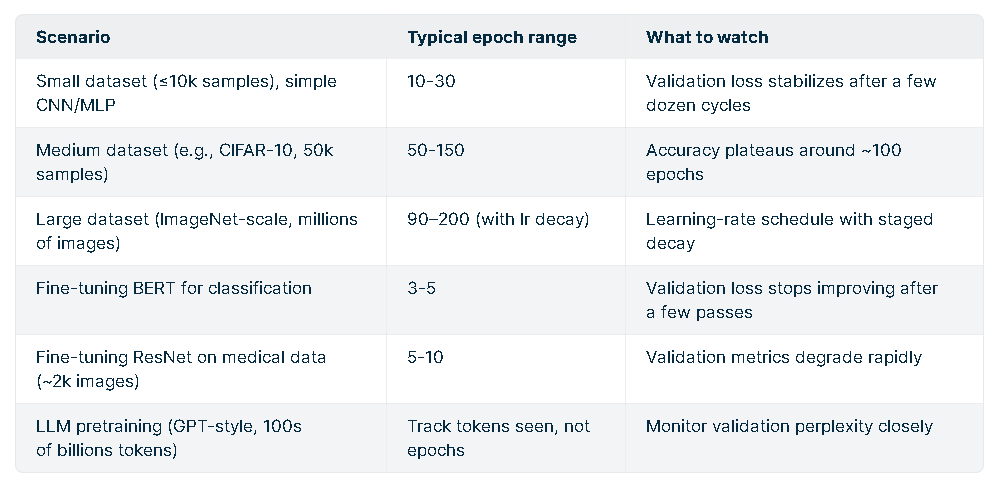<br><br>

How many epochs are needed to fine-tune pretrained models?<br><br>

Fine-tuning pre-trained models typically requires far fewer epochs than training from scratch. The base model already cantains useful representations, so the focus is on adaptation rather than relearning everything. <br><br>

In practice, many NLP and vision tasks converge within 2 to 10 epochs. For example, BERT-based classification typically sees most improvements in the first few passes. In vision tasks, adaptation can be even faster, especially when only the top layers are trained while lower-level features remain frozen. <br><br>

The scale and domain of the dataset also play a kew role. Small datasets, such as those used in medical or highly specialized applications, tend to overfit quickly. Larger, domain-specific corpora, like legal documents or technical manuals, may require more passes to alighn the model's internal representations with the task at hand. <br><br>

The number of trainable layers further influences epoch needs. When most parameters are frozen, only a few epochs are sufficient. If multiple layers are unfrozen, more parameters are updated, requirings longer training, but this also increses the risk of eroding the knowledge embedded in the pretrained base.<br><br>

For these reasons, fine-tuning demands careful monitoring. Prolonged training often harms more than it helps, degradig both validation performance and the pretrained model's general knowledge. Stopping at the right moment ensures the model apapts effectively while preserving its foundational strenghts.<br><br>

How many batches per epoch?<br><br>

An epoch represents a full pass through the training dataset and is divided into steps that iterate over mini-batches. The number of steps in an epoch is calculated as int(N/V), where N = dataset size and B = batch size.<br><br>

Batch size influences not only the number of steps but also the learning dynamics. Smaller batches create noisier gradients, which can help the model avoid sharp minima and sometimes improve generalization. Larger batches, on the other hand produce smoother gradients and speed up convergence, but without careful adjustemnts, such as linear learning rate scaling, warm-up schedules, or strong regularization, they may reduce generalization quality.<br><br>

The number of batches per opoch is therefor shaped not only by the dataset size but also by available computations resurces. A larger batch size reduces the number of iterations and shortens each epoch, but it requires more memory and careful optimizer tuning. Smaller batches lenghten training in terms of epochs, yet each iteration is lighter and often provides more stable validation behaviour.<br><br>

Ultimately, the number of batches per epoch is not an isolated decision - it follows directly from the chosen batch size and training strategy. In practice, engineers balance between efficiency and generalization, selecting a batch size that maximizes hardware usage while maintaining stable validation performance.<br><br>

The number of epochs is not a fixed parameter; it emerges from the interaction of multiple aspects of training. On large datasets, a network needs longer to absorb the underlying statistics, often requiring tens or even hundreds of passes. On small datasets, however, running too many epochs quickly leads to memorization of noise, with metric improvements dissapering after only a few iterations. Data quality also plays a decisive role: mislabeled or noisy samples reduce the benefit of additional epochs, since the model begins fitting artifacts rather than extracting meaningful patterns.<br><br>

Model architecture further shapes convergence speed. Smaller networks with fewer parameters tend to plateau quickly, while deeper or transformer-based models often measure progress not in epochs but in tokens processed or optimization steps. In streaming scenarios, such as training on massive web-scale corpora, the very idea of an epoch becomes less rigid, and progress is monitored mainly through validation curves. For fine-tuning such models, only a handful of adaptation cycles are typically enough to steer pretrained representations towards a new task. <br><br>

Learning rate is another decisive factor. Higher rates accelerate convergence and may reach peak performance within fewer epochs, though they also increase the risk of oscillations or instability. Lower rates ensure steadier reductions in error but demand more iterations. In this way, optimization choices direcly infuence how many epochs are necessary to achieve stable results.<br><br>

Regularization also alters the balance. Dropout, weight decay and strong augmentation improve robustness but slow down convergence, often requiring more epochs to recover performance. To compensate, adaptive learning rate schedules are frequently paired with these methods.<br><br>

Finally, the stopping strategy determines the actual endpoint. Early stopping and dynamic learning rate adjustments allow training to conclude as soon as validation metrics stop improving. Here, the question shifts from 'how many epochs are needed' to 'at which step does the model reach peak validation performance?'.<br><br>

In real-world projects, all these factors combine: dataset scale and quality, network depth, optimizer hyperparameters and regularization strategies collectively determining how long training should run. No single variable sets the epoch count; rather, it is the interplay of all these elements that defines the optimal stopping point.<br><br>

What are the best practices for choosing the correct number of epochs?<br><br>

Defining the right number of epochs in advance is nearly impossible. Even tasks that look similar can behave very differently, and what works for one model may fail for another. The most effective approach is to use a flexible training strategy.<br><br>

A good strating point is to train for just a few epochs to quickly see how the model behaves. At this stage, plotting loss and accuracy curves is essential, as they show whether performance is improving and how fast. If validation metrics keep rising after five to ten epochs, the training run can be extended.<br><br>

To avoid wasting resources, most setups use early stopping. This technique halts training if performance does not improve for several epochs in a row. Often, a patience patameter is added: the model is not stopped immediately at the first plateau but given a few chances to escape a local minimum.<br><br>

Another useful practice is applying dynamic hyperparameter schedules. For example, lowering the learning rate once the error curve stabilizes can help the model reach better results without endlessly adding more epochs.<br><br>

In large-scale projects, automated hyperparameter tuning frameworks such as Optuna or Ray Tune are widely used. These tools can run dozens of experiments in parallel with different epoch counts, learning rates and regularization settings. They save weeks of manual trial and error and deliver more reliable results. <br><br>

In the end, choosing epochs is not about picking a single number, but about setting up a process where the model itself shown you when it is time to stop.<br><br>

As a Conclusion<br><br>

Epochs are not a fixed parameter but a flexible setting shaped by data size, model architectire and training strategy. A simple network may converge in ten epochs, while a large model trained on complex datasets might require hundreds of passes. <br><br>

The key is not to rely on present numbers but to monitor validation metrics. Once they plateau or decline, the model has likely reached its optimal point. Training beyond this often wastes resources and raises the risk of overfitting. That said, advanced scheduling strategies can sometimes push performance further.<br><br>

Practical tools like early stopping, dynamic learning rate schedules and automated hyperparameter tuning make training both efficient and reproducible. For ML engineers managing production infrastructure, this is critical -> every extra epoch consumes GPU hours, cluster time and budget. Finding the right balance saves costs while maintaining accuracy.<br><br>

In the end, the question 'how many epochs are needed?' has no single answer - but there is a universal approach -> track the training curves, watch when metrics stabilize and stop at peak validation performance. This is how real-world machine learning teams achive both model quality and operational efficiency.<br><br>

https://nebius.com/blog/posts/epochs-in-day-to-day-ml-pipelines<br><br>

What is the difference between a shaprm minimum and a flat minimum in a loss landscape? -> in the context of training neural networks<br><br>

Understanding the Loss Landscape<br>
First, a quickly recap. The 'loss landscape' (or 'error surface') is a visualizatio of the loss function of a machine learning model. Think of it as a hilly terrain<br><br>

Loss function -> This function takes the model's parameters (weights and biases) as input and outputs a value representing how 'wrong' the model's predictions are. The goal of training is to find the parameters values the minimize this loss. <br><br>

Parameters -> These are the adjustable knobs and dials of your model.<br><br>

Minima -> These are the 'valleys' in the landspace - points where the loss function has a low value. Ideally, we want to find the minimum.<br><br>

1.Sharp (Narrow) Minima<br>
Definitions -> A sharp minimum is a region in the loss landscape where the loss if very low, but only for a very specific set of parameter values. It is like a deep, narrow valley. A small change in the parameters can lead to a significant increase in the loss.<br><br>

Characteristics -> <br><br>

Steep Gradient -> Around a sharm minumum, the gradient (the direction of the steepest ascent) is very large. This means the optimization algorithm (like gradient descent) will move quickly and dramatically to reach this minimum. <br><br>

Poor Generalization -> This is the big problem. Models that converge to sharm minima tend to overfit the training data. They have esentially memorized the training examples rather than learning the underlaying patterns, They perform well on the training data but poorly on useen data (the validation/test set).<br><br>

Sensitive to Initizalization -> The starting point of the optimization process (the initial values of the parameters) can heavily influence whether the algorithm finds a sharm minimum. Different initializations can lead to very different final results. <br><br>

Analogy -> Imagine a perfectly carved, narrow bowl. If you place a marble in it, it will settle at the bery bottom, but if you nudge it even slightly, it will roll out.<br><br>

2.Flat (Wide) Minima<br>
Definition -> A flat minimum is a region in the loss escape where the loss is low, and a wide range of paramaters values result in a similar low loss. It is like a broad, shallow valley<br><br>

Characterustics -> <br><br>

Gentle Gradient -> Around a flat minimum, the gradient is small. The optimization algorithm moves more slowly and gradually<br><br>

Good generalization -> Models that converge to flat minima tend to generalize better to unseen data. They have learned more roboust, underlaying patterns that are not specific to the training dataset<br><br>

Less sensitive to initialization -> The starting point of the optimization process is less critical. The algorithm is more likely to find a good solution regardless of where it starts<br><br>

Analogy -> Imagine a wide, gently slopping bowl - if you place a marble in it, it can be nudged a bit without rolling out.<br><br>

Here is a table summarizing the key differences:<br><br>

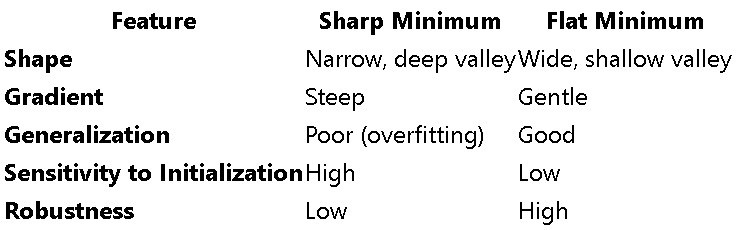<br><br>

Why is it important?<br><br>

Optimization Challanges -> It is often difficult to intentionally find flat minima. Standard gradient descent can easily get stuck in sharp minima. <br><br>

Regularization -> Techniques like L1/L2 regularization, dropout, and data augmentation are often used to encourage the model to find flatter minima. They effectively 'smooth out' the loss landscape, making it more likely to find broader, more generalizable solutions.<br><br>

Batch Size -> Smaller batch sizes during training can sometimes lead to flatter minima, while larger batch sizes can lead to sharper minima. <br><br>

Optimization Algorithms -> More advances optimization algorithms (like Adam, SGD with momentum) can sometimes heap escape minima and find flatter regions. <br><br>

In essence, the goal in training machine learning models to find a flat minumum in the loss landscape, as this leads to better generalization and a more robust model. <br><br>


https://www.truegeometry.com/api/exploreHTML?query=What%20is%20the%20key%20difference%20between%20a%20sharp%20minimum%20and%20a%20flat%20minimum%20in%20a%20loss%20landscape<br><br>

What is an epoch in Machine Learning?<br><br> (will go over whole article simply to reitarate and get it settled even more in my brain)

Machine Learning is the science of developing algorithms that perform tasks without explicit instructions. These algorithms use statistical models to identidy patterns in existing data and make an inference or prediction for new data. For example, ML models analyse an existing data set of prelabbeled cat and dog images. Then, they predict wheather a previously unknown image (not found in the initial training set) is a cat or a dog.<br><br>

Most Machine Learning models are internally made of neural networks. Neural networks are layers of interconnected software components called nodes that work together to process data. Each node looks at different data aspects or features - like eye shape, ear shape, or nose shape and performs mathematical calculations. Results from individual nodes are combined to find the final solution.<br><br>

You must understand the training process to learn more about machine learning and neural networks. <br><br>

What is an epoch?<br><br>

An epoch in machine learning occurs when the machines learning model completes one pass through the training dataset. You can think of this process as going through your entire study meterial once. Every time you read to learn, you complete an epoch in machine learning terms. <br><br>

Data engineers repeatedly feed the same training data to the model so it can identify new patterns and gain a deeper understanding of the data. After every epoch, the model updates its internal mathematical calculations based on the data it was just fed. It mainly adjusts weights and biases, mathematical factors that determine how different neurons affect each other's output.<br><br>

What happends in an epoch?<br><br>

Here is a closer look at what occurs during an epoch<br><br>

- Forward pass -> Each sample in the training dataset is passed through the network to compute the output. This involved using the current values of the network's wieghts and biases to calculate the output for each input sample<br><br>

- Loss Calculation -> After the input is obtained, a loss (or cost) function calculates the prediction error by comparing it to the expected output. This error provides a measure of the network's performance<br><br>

- Backward pass -> The error is then propagated back through the network, updating the weights and biases. This step is critical as it helps to minimize the loss by adjusting the model parameters (weights and biases)<br><br>

- Parameter Update -> The weights and biases are updated. The specific adjustments are determined by the gradients of the loss function with respect to each parameter<br><br>

Number of epochs<br><br>

It is important to metion that the number of epochs needed for model training can vary and is set by the data engineer. In most cases, it depends on the data's complexity and the desired accuracy level. This means traininng can run for tens, hundreds, or even thousands of epochs until the model generates accurate predictions for new data<br><br>

Generally, increasing the number of epochs leads to better model performance because it learns more complex patterns in the data. But be careful; too many epochs may cause the model to overfit! Accuracy drops if the unknown data is too different from the training dataset. For example, if the training data contained only images of cats and dogs in a park, the model may not be able to identify a can on a beach<br><br>

Batch, batch size, iteration<br><br>

A batch is a smaller portion of the entire training dataset. A large training dataset is usually split into smaller groups called batches or mini-batches for efficient model training. The model can process data in smaller chunks without problems like insufficient storage space. The batch determines how many samples will pass before updating the model's weights. <br><br>

The batch size shows the number of training examples in a single batch. For example, 10,000 data samples can be divided into ten batches of batch size 1000. The process of breaking down the dataset is called batch processing.<br><br>

Iteration<br><br>

Every time an algorithm processes a batch, it updates its internal parameters based on that data in preparation for the next batch. This update helps the model improve its performance on the learning task and reduce errors. This is also called an iteration. Multiple iterations make up an epoch.<br><br>

If: <br><br>

-> N = Total Number of Examples <br><br>

-> B = Batch Size <br><br>

-> I = Iteration <br><br>

Then: <br><br>

-> I = N/B<br><br>

-> In 1000 samples of batch size 1000, I = 10000/1000<br><br>

-> Therefor, I = 10<br><br>

-> Therefor, it will take 10 iterations to perform an epoch<br><br>

What is the difference between epoch and batch?<br><br>

A batch is a subsection of the complete training dataset. The quantity of samples in each batch is the batch size. On the other hand, an epoch is when all batches complete one pass through the algorithm.<br><br>

Difference between epochs and batch in a table:<br><br>

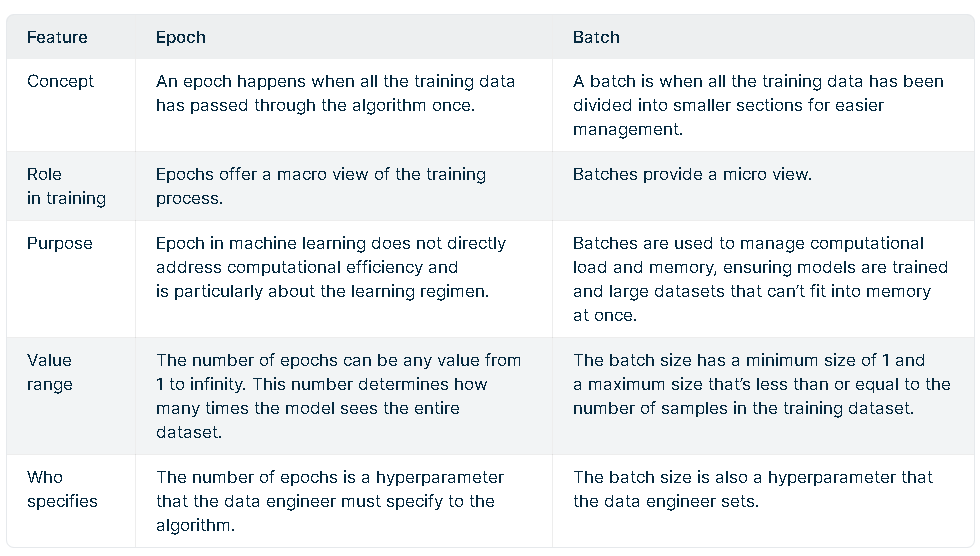<br><br>

How are paramteres updated in an epoch?<br><br>

Parameters are updated when a batch is processed. There are 3 models batch processing:<br><br>

-> Batch Mode -> The entire training dataset is considered a single batch (B=N). This means the model processes the entire dataset at once before updating its internal parameters<br>
              -> One majour advantage of this type of batch processing is that the model can reach convergence (optimal performance) in fewer epochs than other modes<br>
              -> On the flip side, this type of processing is computantionally expensive, particularly for complex models. It will also require a lot of memory to hold the entire dataset. There are also no frequent parameter updates, unlike other modes<br><br>

-> Mini-batch Mode -> This is the most common type of batch processing where the training data is broken down into smaller, manageble groups called mini-batches. The model processes one mini-batch at a time and updates its parameters after each mini-batch. <br>
                   -> With the mini-batch mode, you will rarely run into memory usage problems, meaning more speed. There is also potential for more frequent parameter updates. However, it will require more epochs to converge. You may also need to experiment a few times to find the optimal mini-batch size<br><br>

-> Stochastic Mode -> The stochastic mode uses unique batch sizing, which means the gradient and parameters are changed after each sample. Stochaistic gradient descent (SGD) is the optimization algorithm used to identify the set of internal model parameters that yield the closest match between predicted and actual outputs<br>
                   -> The SGD algorithm leverages the concept of an error gradient to achieve convergence. This esentially means it follows the slope of the error surface with respect to model parameters. It guides the parameter optimization process towards the minimum error level by iteratevly descending this slope. Predictions are generated at each step using a speicific sample and the current parameter set. The dicrepancy between predictions and expected results is quantified as the error. Subsequently, the internal parameters are adjusted to minimize this error in the next iteration <br><br>

Example of epochs in Machine Learning<br><br>

To better understand the concept of an epoch in machine learning, let's quickly discuss a specific example of mini-batch processing. Let's imagine you are training a model to predict movie ratings. Your entire dataset has information on 5000 movies (samples) with details like genre, cast, producer, and director. You could set the training to run for 20 epochs and choose a batch size of 100. <br><br>

Things would work out like this:<br><br>

In the first epoch, the data is shuffled and then split into 50 batches of 100 movies each. The model takes each batch, analyzes the features of the 100 movies, compares its predictions to actual ratings, and adjusts its internal weights. Thus, the model adjusts its weights 50 times across all 50 batches or iterations.<br><br>

Then data engineers shuffle the data, batch it again, and repeat the training process for 19 more epochs. By the end, the model has been exposed to the entire dataset 20 times (completing 20 epochs). During this process, its weights were updated a total of 1000 times as 50 batches/epochs X 20 epochs = 1000 iterations. <br><br>

Why is epoch essential in machine learning?<br><br>

Epochs are important when training machine learning models. An epoch helps to identfy the model that best fits the training data. Here are a few more reasons why this is a crucial concept in ML;<br><br>

- Improved Model Performance -> The number of epochs is an essential hyperparameter during training. Setting too few epochs can cause underfitting, where the model does not accurately learn the patterns in the data. On the flip side, too many epochs can lead to overfitting, where the model does not adequetly learn the patterns in the data. On the flip side, too many epochs can lead to overfittingm where the model become overly tuned to the training data's noise, underlying patterns without memorizing noise by choosing the right number of epochs. <br><br>

- Simplifying Early Stopping -> Monitoring performance metrics across epochs is important for techniques like early stopping. This method halts training when the model's performance on a validation set stops improving or starts to decline. Early stopping can also prevent overfitting and save computational resources.<br><br>

- Better insights into learning dynamics -> As epochs progress, users often get more valuable insights into the model's learning dynamics. For example, by observing how quickly the model learns and when it begins to plateau, users can make informed decisions about adjuting the learning rate, batch size, and other model parameters to improve performance.<br><br>

How to choose the number of epochs?<br><br>

Although more epochs can improve the model's accuracy, it also increases the training time. At the same time, a single epoch is usually not enough to optimally modify the model's total weight because of the need for learning optimization. This makes it important to find a sweet spot to avoid underfitting or overfitting the data.<br><br>

There are a handful of effective techniques for obtaining the optimal number of epochs - including<br><br>

- Early stopping halts training when the model's performance on a validation set starts to decline, preventing overfitting. <br><br>

- Cross-validation splits the training data into multiple folds and trains the model with different epoch values on each fold. The epoch value that performs best on average across the validation folds is then chosen for the final model.<br><br>

- Transfer learning leverages pre-trained models to achieve good results with fewer epochs needed for training compared to training from scratch.<br><br>

As a conclusion -> Epochs and Batch Sizes are essential hyperparameters in training machine learning models. Epochs represent the number of times the entire dataset passed through the algorithm, while batch size determines the number of training samples processed before updating the model's parameters. A batch is a small fraction of the entire dataset that was broken down to make it computantionally efficient to feed the model without losing memory. 

https://nebius.com/blog/posts/epoch-in-machine-learning<br><br>

Convergence in Optimization -> Convergence in Machine Learning optimization represents the moment when an iterative process reaches a stable solution. This section explains the concept in the optimization landscape, introduces the diverse optimization algorithms prevalent in machine learning, and learns about the evaluation of convergence criteria.<br><br>

Convergence -> Convergence is the essence of optimization. It represents iterative refinement toward a stable solution. In machine learning, convergence means the cessation of parameter updates, indicating that further iterations are unlikely to significantly improve the model's performance or reduce the optimization objective. It serves as a critical checkpoint in the training process to ensure that the model has sufficiently learned from the data and has reached an optimal state.<br><br>

Optimization Algorithms -> Machine Learning employs a spectrum of optimization algorithms to iteratively adjust model parameters and minimize an objective function. From classic algorithms like gradient descent to advanced variants such as stochastic gradient descent and Adam optimization landscape. These algorithms differ in their convergence properties, speed, and suitability for different optimization tasks.<br><br>

Covergenge Criteria -> Defining and Evaluating convergence criteria is essential for monitoring and assessing the progress of optimization algorithms. Convergence criteria typically involve metrics such as the change in the optimization objective, the magnitude of parameter updates, or the achievement of a predefined threshold. Additionally, convergence may be inffered based on the algorithm's behavious, such as stabalizing loss curves or consistent parameter values over iterations. Determining appropriate convergence criteria requires careful consideration of the optimization task, model architecture, and computational resources available.<br><br>

Convergence in Neural Networks -> In neural network training, convergence denotes the state where the optimization algorithm has effectively minimized the loss function, which leads to stable and optimal model parameters. It reflects the seccessful learning of patterns and relationships in the data by the neural network, ensuring its ability to generalize well to unseen instances. <br><br>

Gradient Descent -> Gradient Descent stands is an important concept of optimization in neural network training, driving the iterative process of parameter updates toward the direction of the steepest descent of the loss function. It involves computing the gradient of the loss function to the model parameters and adjusting the parameters in the opposite direction of the gradinet to minimize the loss. <br><br>

Different Variants of Gradient Descent Algorithms<br><br>

Several Variants of Gradient Descent Algorithms have been developed to enhance convergence speed and stability in neural network training. These variants include:<br><br>

- Stochaistic Gradient Descent (SGD) -> Updates parameters using gradients computed on a subset of training data (mini-batch), offering faster convergence and reduced computational burden<br><br>

- Batch Gradient Descent -> Computes geadients on the entire training dataset before updating parameters, ensuring more accurate updates but potentially slower convergence, especially for large datasets<br><br>

- Mini-Batch Gradient Descent -> Strikes a balance between SGD and batch gradient descent by updating parameters using gradients computed on a mini-batch of data, offering both efficiency and accuracy in convergence<br><br>

https://mljourney.com/what-is-convergence-in-machine-learning/<br><br>

The learning rate is a key hyperparameter in neural networks that controls how quickly the model learns during training. It determines the size of the steps taken to minimize the loss function. It controls how much change is made in response to the error encountered, each time the model weights are updated. It determines the size of the steps taken towards a minimum of the loss function during optimization. <br>
In Mathematical terms, when using a methods like Stochaistic Gradient Descent (SGD), the learning rate is multiplied by the gradient of the loss function to update the weights.<br><br>

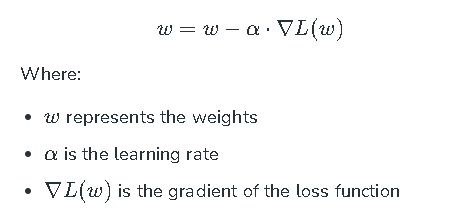<br><br>

Impact of Learning Rate on Model<br><br>

The learning rate is a critical hyperparameter that directly affects how a model learns during training by controlling the magniude of weights updates. Its value significantly affects both convergence speed and model performance.<br><br>

A Low Learning Rate:<br>
- Leads to slow convergence<br>
- Requires more training epochs<br>
- Can improve accuracy but increases computation time<br><br>

A High Learning Rate:<br>
- Speeds up training<br>
- Risks of overshooting optimal weights<br>
- May cause instability or divergence of the loss function<br><br>

An Optimal Learning Rate:<br>
- Balances training speed and model accuracy<br>
- Ensures stable convergence without excessive training time<br><br>

Best practices for learning rates include:<br>
- Fine-tuning the learning rate beased on the task and model<br>
- Use techniques like learning rate scheduling or adaptive optimizers to improve performance and stability<br><br>

Identidying the ideal learning rate can be challanging but is important for improving performance without wasting resources<br><br>

Techniques for Adjusting the Learning Rate:<br><br>

1.Fixed Learning Rate<br>
- A constant learning rate is maintained throughout training<br>
- Simple to implement and commonly used in basic models<br>
- Its limitation is that it lacks the ability to adapt on different training phases which may create sub optimal results<br><br>

2.Learning Rate Schedules<br>
These techniques reduce the learning rate over time based on predefined rules to improve convergence:<br>
- Step Decay -> Reduces the learning rate by a fixed factor at set intervals (every few epochs)<br>
- Exponential Decay -> Continuously decreases the learning rate exponentially over training time<br>
- Polynomial Decal -> Learning rate decays polynomially, offering smoother transitions compared to step or exponential methods<br><br>

3.Adaptive Learning Rate Methods<br>
Adaptive methods adjust the learning rate dynamically based on gradient information, allowing better updates per parameter:<br>
- AdaGrad -> AdaGrad adapts the learning rate per parameter based on the squared gradients. It is effective for sparse data but may decay too quickly<br>
- RMSprop -> RMSprop builds on AdaGrad by using a moving average of sqared gradients to prevent aggressive decay<br>
- Adam (Adaptive Moment Estimation) -> Adam combines RMSprop with momentum to provide stable and fast convergence; widely used in practice<br><br>

4.Cyclic Learning Rate<br>
- The learning rate oscillates between minimum and maximum value in a cyclic manner throughout training<br>
- It increases and then decreases the learning rate linearly in each cycle<br>
- Benefits include better exploration of the loss surface and leading to faster convergence<br><br>

5.Decaying Learning Rate<br>
- Gradually reduces the learning rate as training progresses<br>
- Helps the model take more precise steps towards the minimum. This improves stability in later epochs<br><br>

Achieving optimal learning rater is essential as to low results in long training times while too high can lead to model instability. By using various techniques we optimize the learning process, ensuring accurate predictions without unnecessary resource expenses.<br><br>

https://www.geeksforgeeks.org/machine-learning/impact-of-learning-rate-on-a-model/<br><br>

Understanding PyTorch Learning Rate Scheduling<br><br>

In the realm of deep learning, PyTorch stands as a beacon, illuminating the path for researchers and practitioners to traverse the complex landscapes of artificial intelligence. Its dynamic computational graph and user-friendly interface have solidified its position as a preferred framework for developing neural networks. As we dvelve into the nuances of model training, one essential aspect that demands meticulous attention is the learning rate. To navigate the fluctuating terrains of optimization effectively, PyTorch introduces a potent ally - the learning rate scheduler. This article aims to demystify the PyTorch learning rate scheduler, and indispensable role in enhancing the efficiency the efficacy of model training.<br><br>

PyTorch Learning Rate Scheduler<br><br>

PyTorch, an open source machine learning library, has gained immense popularity for its dynamic computation graph and ease of use. Developed by Facebook's AI Research lab (FAIR), PyTorch has become a go-to framework for building and training deep learning models. Its flexibility and dynamic nature make it particularly well-suited for research and experimentation, allowing practicioners to initiate swiftly and explore innovative approaches in the ever-evolving field of artificial intelligence.<br><br>

What is Learning Rate Scheduler?<br><br>

At the heart of effective model training lies the learning rate - a hyperparameter crucial for controlling the step size during optimization. PyTorch provides a sophisticated mechanism, known as the learning rate scheduler, to dynamically adjust the hyperparameter as the training progresses. The syntax for incorporating a learning rate scheduler into your PyTorch training pipeline is both intuitive and flexible. At its core, the scheduler is integrated into the optimizer, working hand in hand to regulate the learning rate based on predefined policies. The typical syntax for implementing a learning rate scheduler involves instantiating an optimizer and a scheduler, then stepping through epochs or batches, updating the learning rate accordingly. The versatility of the scheduler is reflected in its ability to accomodate various parameters, allowing practitioners to tailor its behavious to meet specific training requirements.<br><br>

Parameters and their Significance<br><br>

- Optimizer -> Establishes the connection between the PyTorch learning rate scheduler and the optimizer responsible for updating the model parameters<br>
- Step Size -> Dictates the number of epochs between each adjustment of the learning rate, influencing how often the learning rate is updated during training<br>
- Gamma -> Scales the learning rate after each step, controlling the rate at which the learning rate decays or grows<br>
- Last Epoch -> A parameter that aids in resuming training from a specific epoch, providing flexibility in model development and training management<br><br>

Need for Learning Rate<br><br>

The importance of learning rate schedules becomes evident when considering the dynamic nature of model training. As models traverse complex loss landscapes, a fixed learning rate may hinder convergence or cause overshooting. Learning rate schedules address this challange by adapting the learning rate based on the model's performance during training. This ability is crucial for avoiding divergence, accelerating convergence, and facilitating the discovery of optimal model parameters. <br><br>

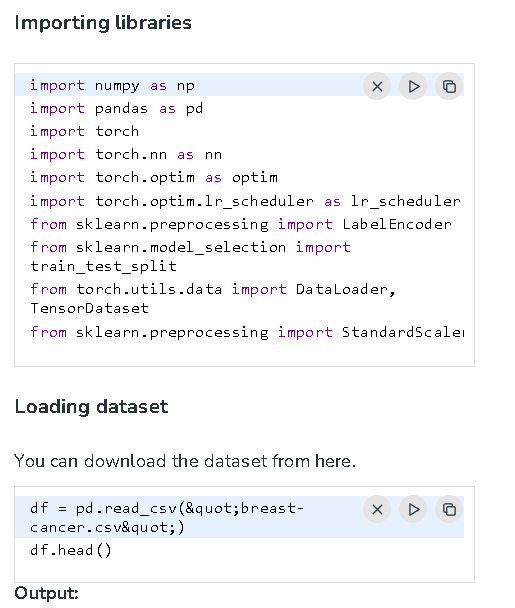<br><br>

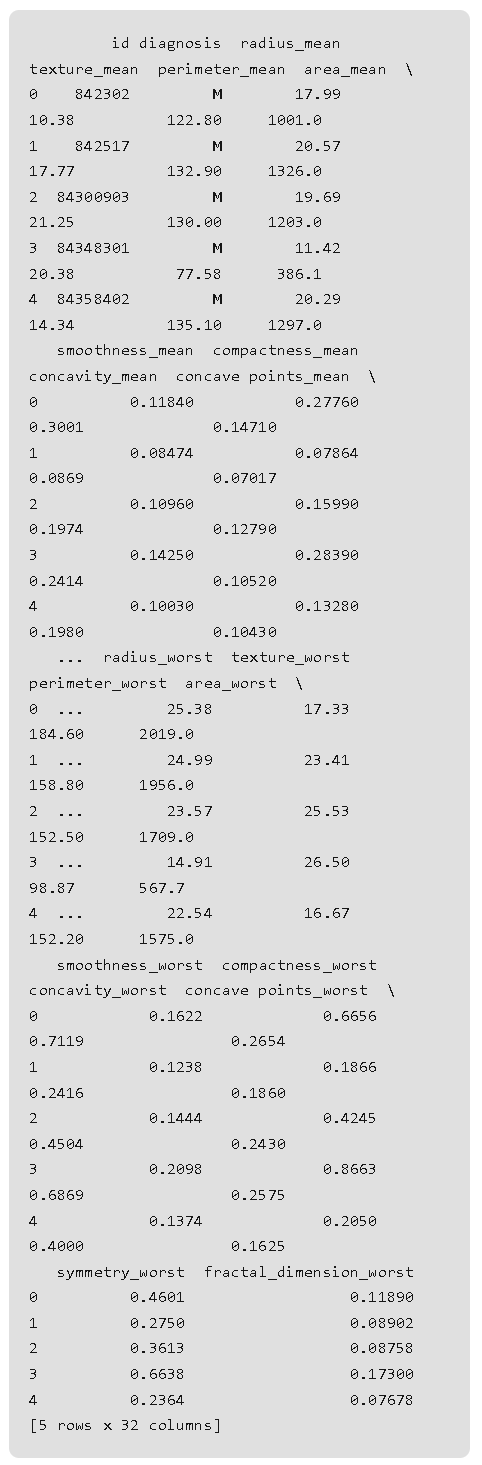<br><br>

Data Extracting and Encoding<br><br>

- X is a DataFrame containing features, excluding the 'diagnosis' and 'id' columns from the original DataFrame df<br>
- y is a Series containing the targer variable 'diagnosis' from the original DataFrame df<br><br>
- The values in the 'diagnosis' column of y are mapped to numerical values: 'M' (Malignant) is mapped to 1, and 'B' (Benign) is mapped to 0<br>
- X represents the features, while y represents the target variable<br><br>

Train test split and standardisation<br><br>

- The train_test_split function from scikit-learn is used to split the dataset (X and Y) into testing and training sets<br>
- X_train and X_test are the training and testing sets of features, respectively<br>
- Y_train and Y_test are the corresponding training and testing sets of target labels<br>
- A StandardScaler instance is created, which is a preprocessing step to standardize the features<br>
- X_train_std is obtained by fitting the scaler on X_train and then transforming it. This ensures that the training data has a mean of 0 and a standard deviation of 1<br>
- X_test_std is stadardised using the parameters learned from the training data (X_train), ensuring consistency in the scaling process<br>
- random_state = 2 is set for reproducibility. This ensures that if you run the code multiple times, you get the same train-test split<br><br>

Tensor dataset and Dataloader<br><br>

- The NumPy arrays X_train_std and Y_train are converted by PyTorch tensors using torch.FloatTensor<br>
- Y_train_tensor is reshaped using .view(-1, 1) to ensure it has a proper shape for model compatibility. The -1 is used to automatically infer the size based on the lenght of the array, and 1 indicates a single column<br>
- Similarly, the test set features (X_test_std) and target labels (Y_test) and converted to PyTorch tensors using torch.FloatTensor. The targer tensor is also reshaped<br>
- A TensorDataset is created for the training data, combining the features (X_train_std_tensor) and targets (Y_train_tensor) into a single dataset<br>
- DataLoader is then used to create an iterator over the dataset with a specified batch size of 32 and shuffling the data (shuffle = true)<br><br>

X_train_std_tensor = torch.FloatTensor(X_train_std)<br>
Y_train_tensor = torch.FloatTensor(Y_train.values).view(-1, 1) <br><br>

X_test_std_tensor = torch.FloatTensor(X_test_std)<br>
Y_test_tensor = torch.FloatTensor(Y_test.values).view(-1, 1) <br><br>

train_dataset = TensorDataset(X_train_std_tensor, Y_train_tensor)<br>
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)<br><br>

Model Creation<br><br>

- Input Layer -> 30 features<br>
- Hidden Layers -> two hidden layers wiht 64 and 32 units, respectively<br>
- Activation Functions -> ReLU after each hidden layer, Sigmoid at the output<br>
- Output Layer -> Single unit for binary classification<br><br>

model = nn.Sequential(<br>
    nn.Linear(30, 64),  # Input layer with 30 features, hidden layer with 64 units<br>
    nn.ReLU(),<br>
    nn.Linear(64, 32),  # Hidden layer with 32 units<br>
    nn.ReLU(),<br>
    nn.Linear(32, 1),   # Output layer with 1 unit (for binary classification)<br>
    nn.Sigmoid()<br>
)<br><br>

Loss function and optimizer<br><br>

- Criterion = nn.BCELoss(): Binary Cross Entropy Loss is chosen as the loss function, suitable for binary classification tasks<br>
- Optimizer = optim.Adam(model.parameters(), lr = 0.001): Adam optimizer is used for gradient-based optimization wiht a learning rate of 0.001<br><br>

criterion = nn.BCELoss()<br>
optimizer = optim.Adam(model.parameters(), lr=0.001)<br><br>

Learning Rate Scheduler<br><br>

- Learning rate is adjusted using StepLR scheduler, reducing it by a factor of 0.5 every 20 epochs<br><br>

scheduler = lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)<br><br>

num_epochs = 50<br><br>

Training Loop<br><br>

- For epoch in range(num_epochs) -> iterating through a specified number of epochs (50 in this case)<br>
- Model.train() -> Sets the model to training mode<br>
- Loop over batches from train_loader<br>
- Outputs = model(inputs) -> Forward pass to obtain model predictions<br>
- Targets = targets.unsqueeze(1).float() -> Adjusting the shape of targer tensor<br>
- Loss = criterion(outputs, targets.view(-1 ,1)) -> Calculating the binary cross-entropy loss<br>
- Backward pass, gradient update, and learning rate adjustment<br><br>

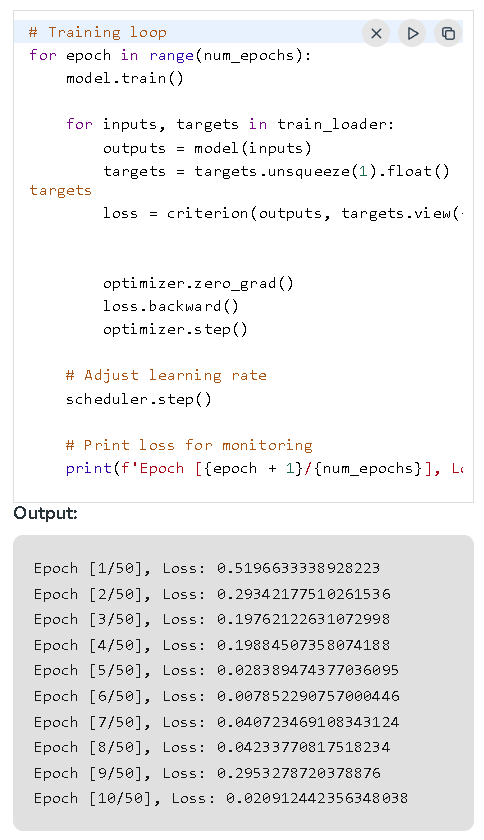<br><br>

Evaluation Metrics<br><br>

- Model.eval() -> Sets the model to evaluation mode<br>
- With torch.no_grad() -> Temporarily disables gradient computation during evaluation<br>
- Test_outputs = Model(X_test_std_tensor) -> Forward pass on the test set<br>
- Test_predictions = (test_outputs >= 0.5).float() -> Converting model probabilities to binary predictions using a threshold of 0.5<br>
- Accuracy = (test_predictions == Y_test_tensor).float().mean().item() -> Calculating accuracy based on binary predictions and true labels<br>

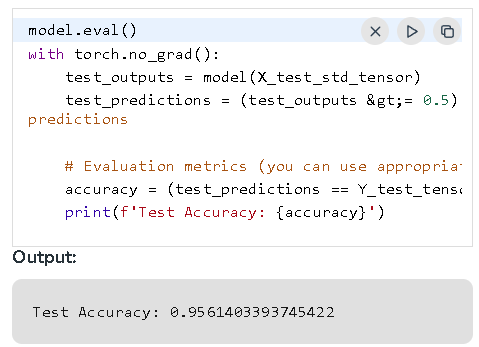<br><br>

The provided test accuracy of appoximately 95.6% suggests that the training neural network model performs well on the test set<br><br>

Applications of PyTorch learning rate schedulers<br><br>

The applications by PyTorch learning rate schedulers are multifaceted. They play a pivotal role in fine-tuning models for specific tasks, improving convergence speedm and aiding in the exploration of diverse
hyperparameter spaces. Learning rate shcedulers find particular relevance in scenarios where the loss landscape is non-uniform, and traditional fixed learning rates prove suboptimal. Applications range form image classification and object detection to natural language processing, where the ability to dynamically adjust the learning rate can be a game-changer in achieving superior model performance.<br><br>

https://www.geeksforgeeks.org/deep-learning/understanding-pytorch-learning-rate-scheduling/<br><br>

Adagrad Optimizer in Deep Learning<br><br>

Adagrad (Adaptive Gradient Algorithm) is an optimization method that adjust the learning rate for each parameter during training. Unlike standard gradient descent with a fixed rate, Adagrad uses past gradients to scale
updates making it effectove for sparse data and varying feature magnitudes.<br><br>

Working Adagrad<br><br>

The primary concept behind Adagrad is the idea of adapting the learning rate based on the historical sum of squared gradients for each parameter. Here's a step-by-step explanation of how Adagrad works:<br><br>

1. Initialization -> Adagrad begins by initializing the parameter values randomly, just like other optimization algorithms. Additionally, it initializes a running sum of squared gradients for each parameter which will track the gradients over time<br>
2. Gradient Calculation -> For each training step, the gradient of the loss function with respect to the model's parameters is calculated, just like in standard gradient descent<br>
3. Adaptive Learning Rate -> The key difference comes next; instead of using a fixed learning rate, Adagrad adjusts the learning rate for each parameter based on the accumulated sum of squared gradients<br><br>

The updated learning rate for each parameter is calculated as follows:<br>

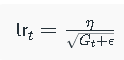<br><br>

Where:<br>
- n is the learning rate (a small constant value)<br>
- Gt is the sum of squared gradients for a given parameter up to time step t<br>
- e is a small value added to avoid division by zero (often set to 1e - 8)<br><br>

Here, the demoninator  grows as the squared gardients accumulate, causing the learning rate to decrease over time which helps to stabalize the training.<br><br>

4. Parameter Update -> The model's parameters are updated by subtracting the product of the adaptive learning rate and the gradient at each step:<br><br>

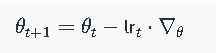<br><br>

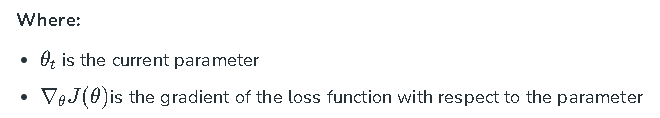<br><br>

When should Adagrad be used?<br><br>

Adagrad is ideal for:<br>
- Problems with sparse data and features like in natural language processing or recommender systems<br>
- Tasks where features have different level of importance and frequency<br>
- Training models that do not require a very fast convergence rate but benefit from a more stable optimization process<br><br>

However, if you are dealing with problems where a more constant learning rate is preferable, using variants like RMSProp or Adam might be more appropriate.<br><br>

Different Variants of Adagrad Optimizer<br>
To address some of Adagrad's drawbacks, a few improved versions have been created like:<br><br>

1.RMSProp (Root Mean Square Propagation):<br><br>

RMSProp addresses the diminishing learning rate issue by introducing an exponentionally decaying average of the squared gradinets instead of accumulating the sum. This prevents the learning rate from decresing too quickly, making the algorithm more effective in training deep neural networks.<br><br>

The update rule for RMSProp is as follows:<br><br>

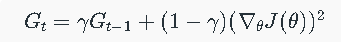<br><br>

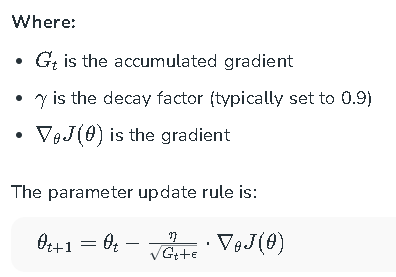<br><br>

2.AdaDelta<br><br>

AdaDelta is another modification of Adagrad that focuses on reducing the accumulation of past gradients. It updates the learning rates based on the moving average of past gradients and incorporateds a more stable and bounded update rule.<br><br>

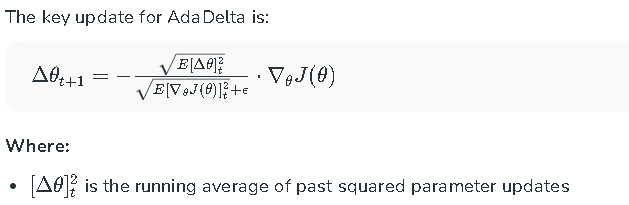<br><br>

3.Adam (Adaptive Moment Estimation)<br><br>

Adam combines the benefits of both Adagrad and momentum-based methods. It uses both the moving average and the squared gradients to adapt the learning rate. Adam is widely used due to its robustness and superior performance in various machine learning tasks.<br><br>

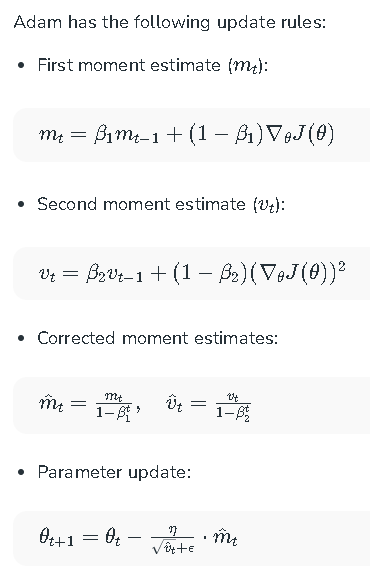<br><br>

1. TensorFlow Implementation<br><br>

In TensorFlow, implementing Adagrad is easier as it is already included in the API. Here is an example where:<br>
- mnist.load_data() loads the MNIST dataset<br>
- reshape() flattens 28X28 images into 784-lenght vectors<br>
- Dixision by 255 nomalizes pixes values to [0,1]<br>
- tf.keras.Sequantial() builds the neural network model<br>
- tf.keras.layers.Dense() creates fully connected layers<br>
- activation = 'relu' adds non-linearity in hidden layer and softmax outputs probabilities<br>
- tf.keras.optimizers.Adagrad() applies adaptive learning rates per parameter to improve convergence<br>
- compile() configures training with optimizer, loss function and metrics<br>
- loss = 'sparse_categorical_crossentropy' computes loss for integer class labels<br>
- model.fit() trains the model for specified epochs on the training data<br><br>

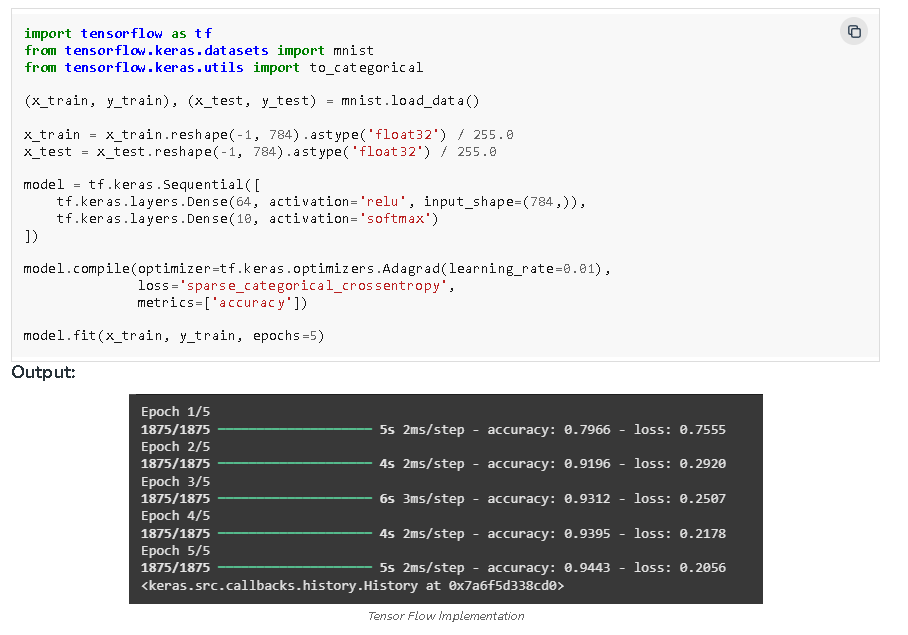<br><br>

2. PyTorch Implementation<br><br>

In PyTorch, Adagrad can be used with the torch.optim.Adagrad class. Here is an example where:<br>
- datasets.MNIST() loads data. ToTensor() converts images and Lambda() flattens them <br>
- DataLoader batches and shuffles data<br>
- SimpleModel has two linear layers with ReLU in forward()<br>
- CrossEntropyLoss computes classification loss<br>
- Adagrad optimizer adapts learning rates per parameter based on past gradients, improving training on sparse or noisy data<br>
- Training loop -> zero gradients, forward pass, complete loss, backpropagate and update weights with Adagrad<br><br>

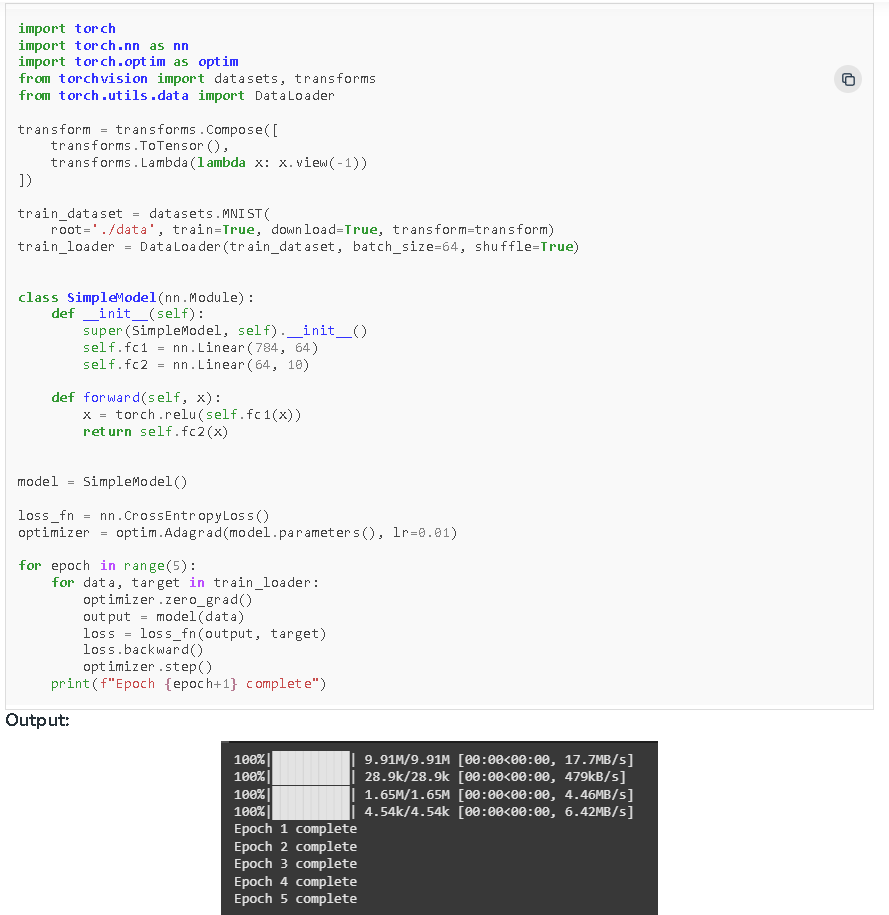<br><br>

By applying Adagrad in appropriate scenarios and complimeting it with other techniques like RSProp and Adam, practitioners can achieve faster convergence and improved model performance.<br><br>

Advantages<br><br>

- Adapts learning rates for each parameter, helping with sparse features and noisy data<br>
- Works well with sparse data by givign rare but important features appropriate updates<br>
- Automatically adjusts learning rates, eliminating the need for manual tuning<br>
- Improves performance in cases with varying gradient magnitudes, enabling efficient convergence<br><br>

Limitations<br><br>

- Learning rates shrink continuously during training which can slow convergence and cause early stopping<br>
- Performance depends heavily on the initial learning rate choice<br>
- Lacks momentum, making it harder to escape shallow local minima<br>
- Learning rates decrease as gradients accumulate which helps avoid overshooting but may hinder progress later in training<br><br>

https://www.geeksforgeeks.org/machine-learning/intuition-behind-adagrad-optimizer/<br><br>

RMSProp Optimizer in Deep Learning<br><br>

RMSProp (Root Mean Square Propagation) is an adaptive learning rate optimization algorithm designed to improve the performance and speed or training deep learning models.<br><br>

- It is a variant of the gradient descent algorithm which adapts the learning rate for each parameter individually by considering the magnitude of recent gradients for those parameters<br>
- This adaptive nature helps in dealing with the challanges of non-stationary objectives and sparse gradients commonly excountered in deep learning tasks<br><br>

Need of RMSProp Optimizer<br><br>

RMSProp was developed to address the limitations of previous optimization methods such as SGD (Stochaistic Gradient Descent) and AdaGrad as SGD uses a constant learning rate which can be infficient and AdaGrad reduces the learning rate too aggressively.<br><br>

RMSProp balances by adapting the learning rates based on a moving average of sqared gradients. This approach helps in maintaining a balance between efficient convergence and stability during the training process making PMSProp a widely used optimization algorithm in moderam deep learning.<br><br>

How does RMSPropr work?<br><br>

RMSProp keeps a moving average of the squared gradients to normalize the gradient updates. By doing so it prevents the learning rate from becoming too small which was a drawback in AdaGrad and ensures that the updates are appropriately scaled for each parameter. This mechanism allows RMSProp to perform well even in the presence of non-stationary objectives making it suitable for training deep learning models.<br><br>

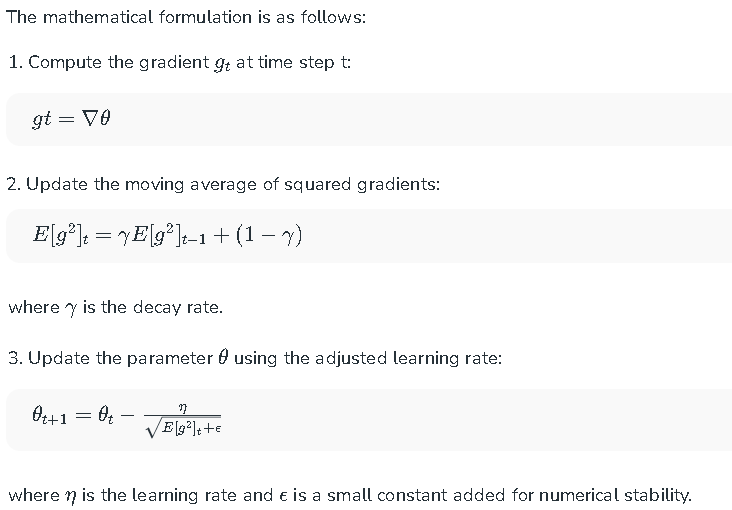<br><br>

Parameters Used in RMSProp<br><br>

- Learning Rate : Controls the step size during the parameter updates. RMSProp typically uses a default learning rate of 0.0001, but it can be adjusted in the specific problem.<br>
- Decay Rate : Determines how quickly the moving average of squared gradients decays. A common default value is 0.9 which balances the contribution of recent and past gradients.<br>
- Epsilon : A small constant added to the demoninator to prevent division by zero and ensure numerical stability. A typical value for e is 1e-8<br><br>

By carefully adjusting these parameters, RMSProp effectively adapts the learning rates during training, leading to faster and more reliable convergence in deep learning models.<br><br>

Implementing RMSprop in Python using TensorFlow or Keras<br><br>

We will use the following code line for initializing the RMSProp optimizer with hyperparameters:<br><br>

tf.keras.optimizers.RMprop(learning_rate=0.001, rho=0.9)<br><br>

- Learning Rate = 0.001 -> Sets the step size for weight updates. Smaller learning rates result in smaller updates, helping to find-tune and prevent overshooting the minimum loss<br>
- rho = 0.9 -> The discounting factor for the history of gradients, controlling the influence of past gradiens on the current gradient computation<br><br>

1. Improting Libraries<br><br>

We are importing libraries to implement RMSprop optimizer, handle datasets, build the model and plot results<br>
- tensorflow.keras for deep learning components<br>
- matplotlob.pyplot for visualization<br><br>

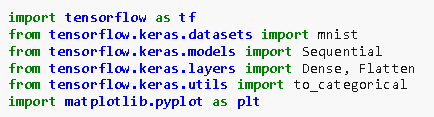<br><br>

2. Loading and Preprocessing Dataset<br><br>

We load the MNIST dataset, mormalize pixel values to [0,1] and one-hot encode labels<br><br>

- mnist.load_data() -> loads images and labels<br>
- Normalization improves training stability<br>
- to_categorical() converts labels to one-hot vectors<br><br>

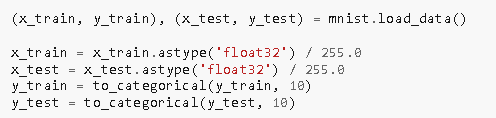<br><br>

3. Building the Model<br><br>

We define a neural network using Sequential with input flatenning and dense layers<br><br>

- Flatten converts 2D images to 1D vectors<br>
- Dense layers learn patterns with REly and softmax activations<br><br>

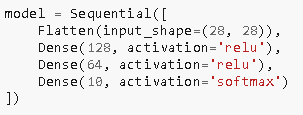<br><br>

4. Compiling the Model<br><br>

We compile the model using the RMSprop optimizer for adaptive learning rates, categorical cross-entropy loss for multi-class classification and track accuracy metric.<br><br>

- RMSprop adjusts learning rates based on recent gradients (parameter rho controls decay rate)<br>
- categorical_crossentropy suits one-hot encoded labels<br><br>

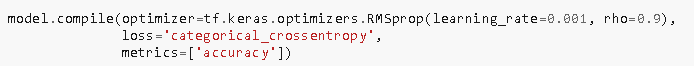<br><br>

5. Training the Model<br><br>

We train the model over 10 epochs with batch size 32 and validate on 20% of training data. validation_split monitors model performance on unseen data each epoch<br><br>

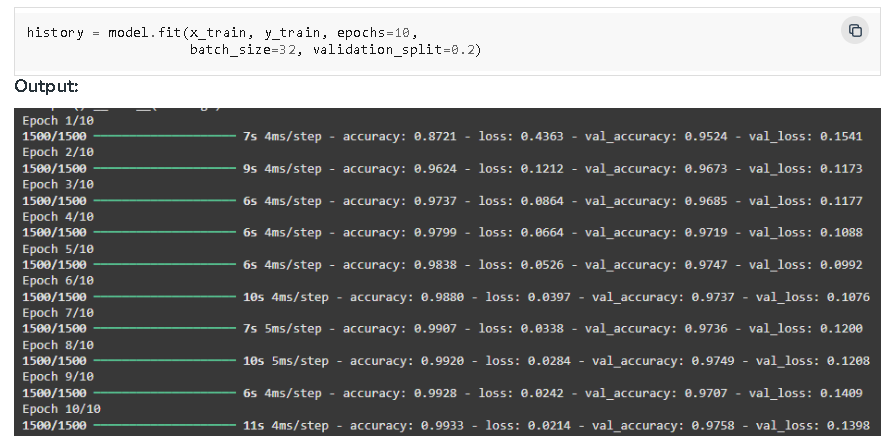<br><br>

6. Evaluating and Visualizing Results<br><br>

We evaluate test accuracy on unseen test data and plot training and validation loss curves to visualize learning progress<br><br>

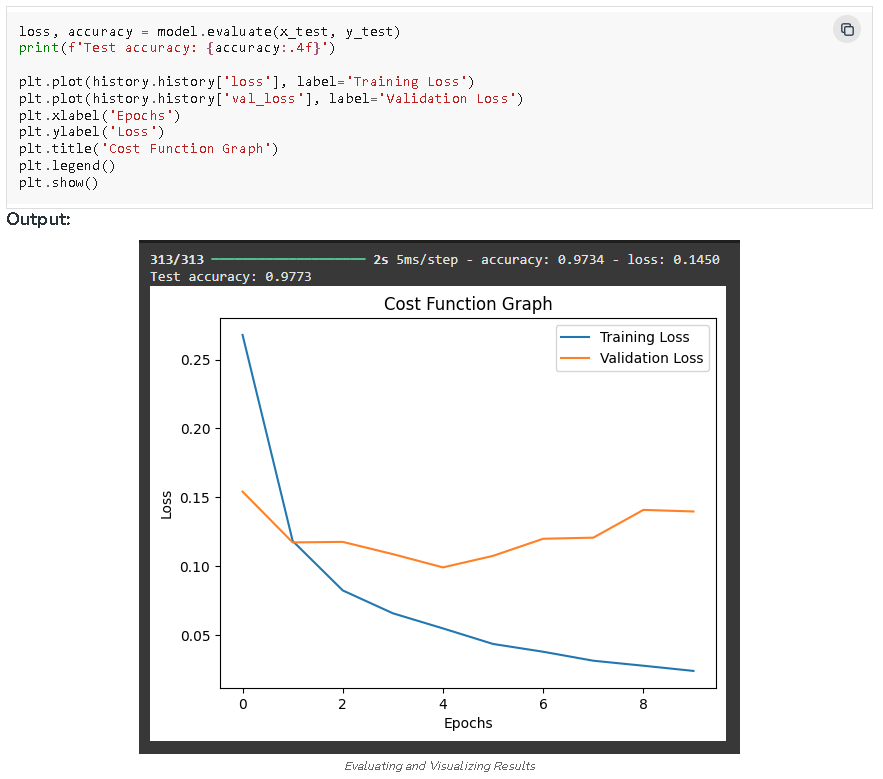<br><br>

Advantages<br><br>

- Adaptive Learning Rates -> Adjusts learning rates for each parameter individually, optimizing updates more effectively<br>
- Handles Non-Stationary Objecives -> Efficiently adapts to changing optimal parameter values over time<br>
- Prevents Learning Rate Decay Problem -> Maintains optimal learning rates by using a decay rate unlike AdaGrad<br>
- Improved Convergence Speed -> Faster convergence due to balanced and dynamic learning rates<br><br>

Disadvantages<br><br>

- Sensitivity to Hyperparameters -> Performance is sensitive to setting like decay rate and opsilon meaning it requires careful consideration<br>
- Poop Performance with Sparse Data -> May struggle with sparse data, leading to slower or inconsistent convergence<br><br>

https://www.geeksforgeeks.org/deep-learning/rmsprop-optimizer-in-deep-learning/<br><br>

What is Adam Optimizer?<br><br>

Adam (Adaptive Moment Estimation) optimizerconbiner the advantage of Momentum and RMSProp techniques to adjust learning rates during training. It works well with large datasets and complex models because it uses memory efficiently and adapts the learning rate for each parameter automatically.<br><br>

How does Adam work?<br><br>

Adam builds upon two key concepts in optimization:<br><br>

1. Momentum<br>
Momentum is used to accelerate the gradient descent process by incorporating an exponentially weighed moving average of past gradients. This helps smooth out the trajectory of the optimization allowing the algorithm to converge faster by reducing oscillations.<br><br>

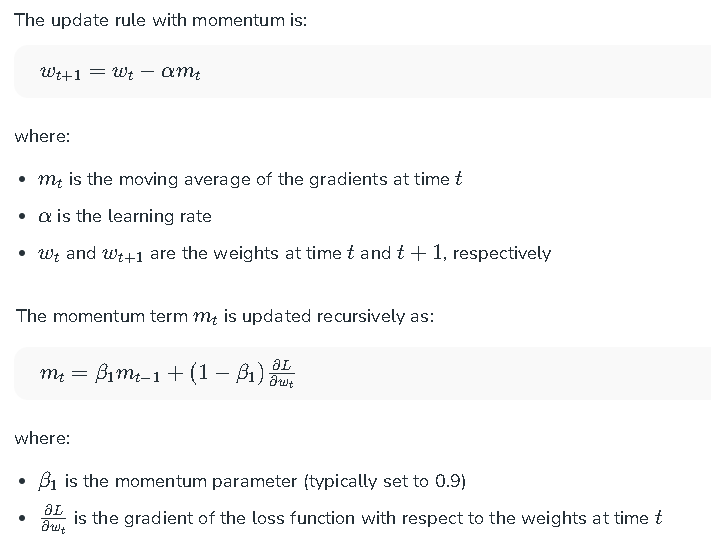<br><br>

2. RMSporp (Root Mean Square Propagation)<br>
RMSprop is an adaptive learning rate method that improves upon AdaGrad. While AdaGrad accumulates squared gradients and RMSprop uses an exponentially weighed moving average of squared gradients, which helps overcome the problem of diminishing learning rates.<br><br>

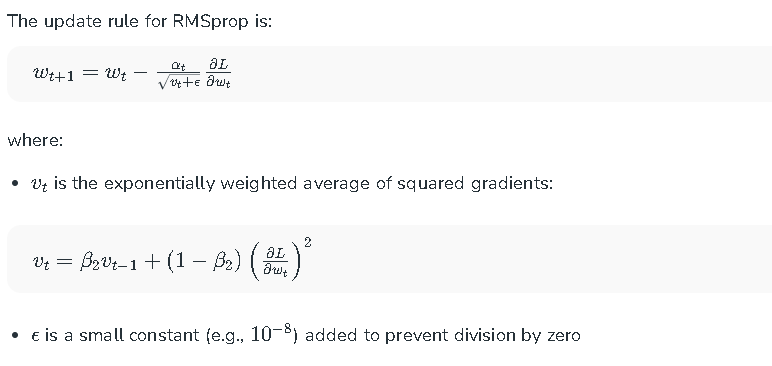<br><br>

Combining Mmentum and RSMprop to form Adam Optimizer<br>
Adam optimizer combines the momentum and RMSprop techniques to provide a more balanced and efficient optimization process. The key equations governing Adam are as follows:<br><br>

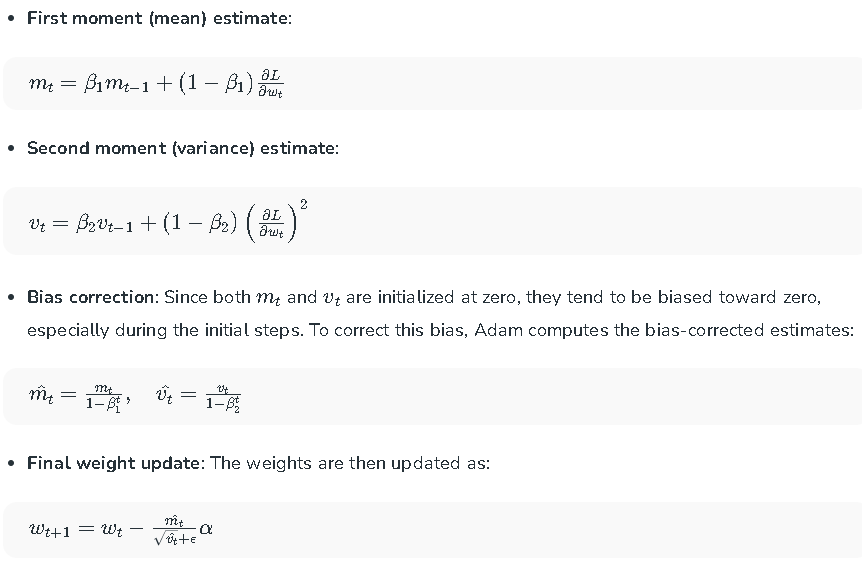<br><br>

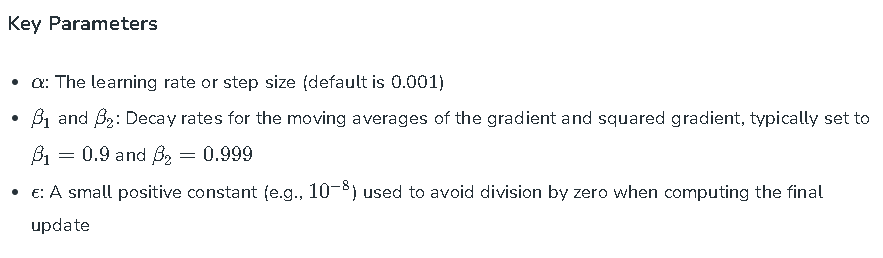<br><br>

Why Adam works so well?<br>
Adam addresses several challanges of gradient descent optimization:<br><br>

- Dynamic learning rates -> Each parameter has its own adaptive learning rate based on past gradients and their magnitudes. This helps the optimizer avoid oscillations and get past local minima more effectively.<br>
- Bias correction -> By adjusting for the initial bias when the first and second moment estimates are close to zero helping to prevent early-stage isntability.<br>
- Efficient performance -> Adam typically required fewer hyperparameter tuning adjustments compared to other optimization algorithms like SGD making it a more convenient choice for most problems.<br><br>

Performance of Adam<br><br>

In comparison o other optimizers like SGD (Stochaistic Gradient Descent) and moemntim based SGD, Adam outperforms them significantly in terms of both training time and convergence accuracu . Its ability to adjust the learning rate per parameter combined with the bias-correction mechanism leading to faster convergence and more stable optimization. This makes Adam especially useful in complex models with large datasets as it avoids slow convergence and instability while reaching the global minimum.<br><br>

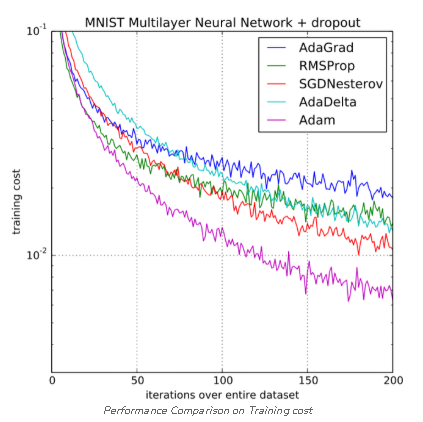<br><br>

In practice, Adam often achives superior results with minimal tuning, making it a go-to optimizer for deep learning tasks.<br><br>

https://www.geeksforgeeks.org/deep-learning/adam-optimizer/<br><br>

ML - Stochaistic Gradient Descent (SGD)<br><br>

Stochaistic Gradient Descent is an optimization algorithm in machine learning, prticulalry when dealing with large datasets, it is a veriant of the traditional gradient descent algorithm but offers several advantages in terms of efficiency and scalability making it the go-to method for many deep-learning tasks.<br><br>

Working of Stochaistic Gradient Descent<br><br>

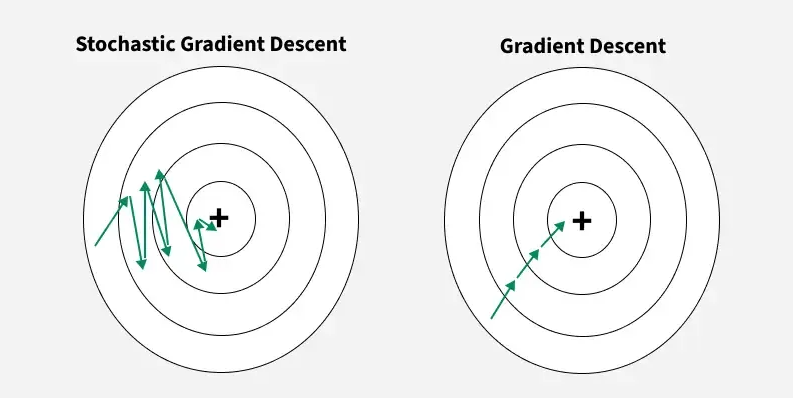<br><br>

- In traditional gradient descent, the gradients are computer based on the entire dataset which can be computantionally expensive for large datasets.<br>
- In Stochastic Gradient Descent, the gardient is calculatet for each training example (or a small subset of training examples) rather than the entire dataset.<br><br>

Stochastic Gradient Descent update rule is:<br><br>

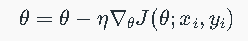<br><br>

Where:<br><br>

- xi and yi represent the features and target of the i-th training example.<br>
- The gradient  is now calculated for a single data point or a small batch<br><br>

The key difference from traditional gradient descent is that, in SGD, the parameter updates are made on a single data point, not the entire dataset. The random selection of data points introduces stockasticity which can be both an average and a challange.<br><br>

Implementing Stochastic Gradient Descent from Scratch <br><br>

1. Generating the Data<br><br>

In the step, we generate synthetic data for the linear regression problem. The data consists of feature X and the target Y where the relationship is linear; e.g.: y = 4 + 3 * X + noise.<br><br>

- X is a random array of 100 samples between 0 and 2<br>
- Y is the target, calculating using a linear equasion with a little random noise to make it more realistic<br><br>

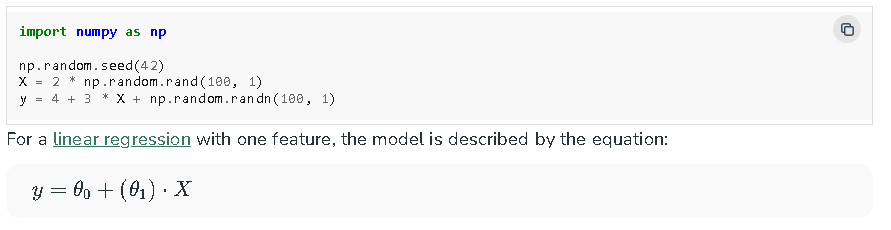<br><br>

Where:<br><br>

- O0 is the intercept (the bias term)<br>
- O1 is the slope or coefficient associated with the input feature X<br><br>

2. Defining the SGD Function<br><br>

Here we define the core function for Stochastic Gradient Descent (SGD). The function takes the input data X and Y. It initializes the model parameters, performs stochastic updates for a specified number of epochs and records tge cost at each step.<br><br>

- theta  is the parameter vector (intercept and slope) initialized randomly<br>
- X_bias is the augmented X with a column of ones added for the bias term (intercept)<br><br>

In each epoch, the data is shuffled and for eacg mini-batch (or single sample), the gradient is calculated and the parameters are updated. The cost is calculated as the mean squared error and the history of the cost is recorded to monitor convergence.<br><br>

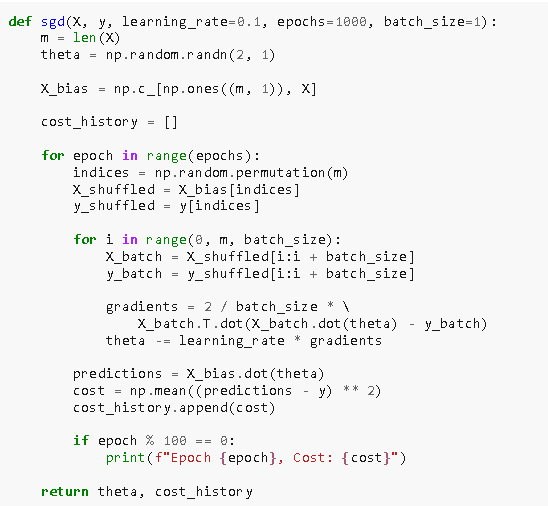<br><br>

3. Train the Model Using SGD<br><br>

In this step, we call the sgd() function to train the model. We specify the learning rate, number of epochs and batch size for SGd.<br><br>

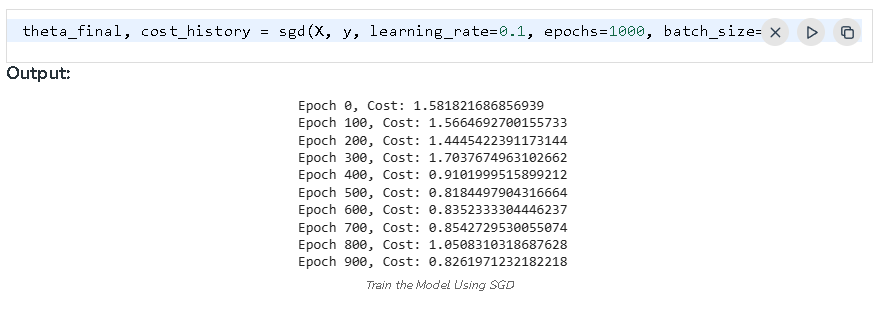<br><br>

4. Visualizing the Cost Function<br><br>

After training, we visualize how the cost function evolves over epochs. This helps us understand if the algorithm is converging properly.<br><br>

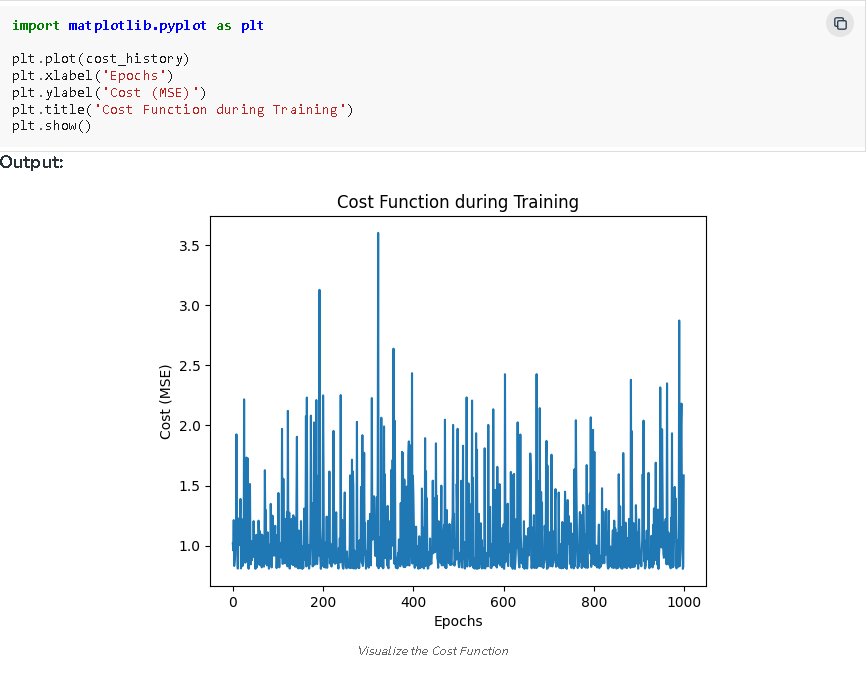<br><br>

5. Plotting the Data and Regression Line<br><br>

We will visualize the data points and the fitted regression after training. We plot the data points as blue dots and the predicted line (from the final 0) as a red line.<br><br>

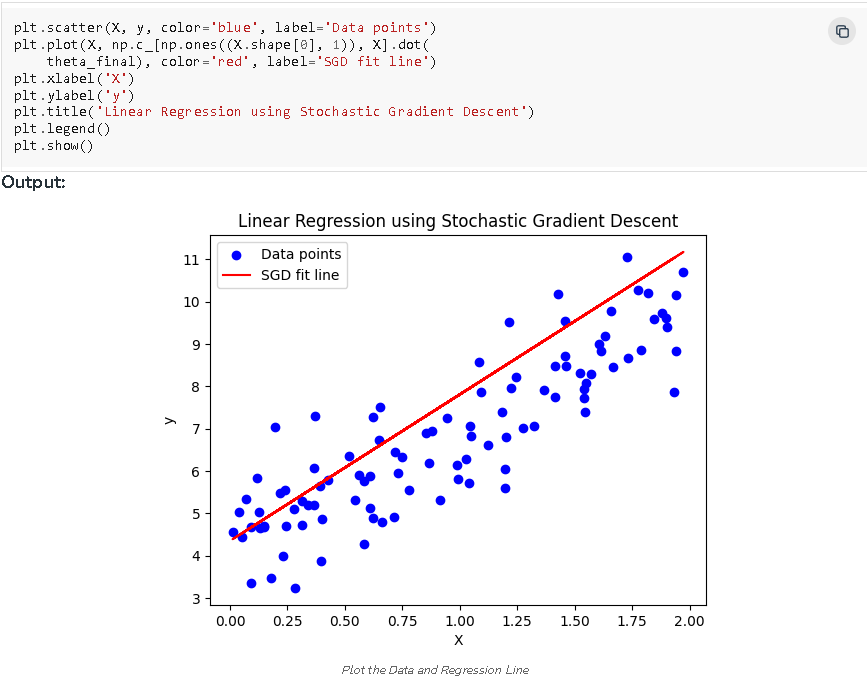<br><br>

6. Printing the Final Model Parameters<br><br>

After training, we print the final parameters of the model which include the slope and intercept. There values are the result of optimizing the model using SGD.<br><br>

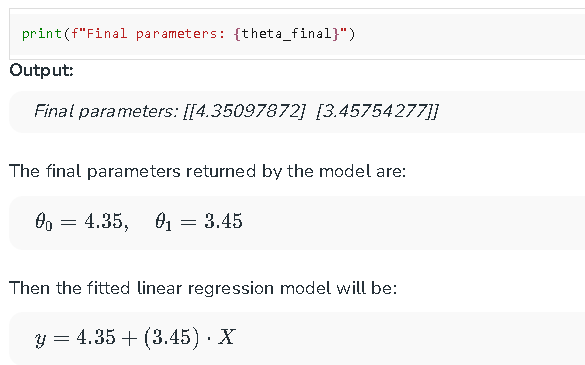<br><br>

This means:<br><br>

- When X = 0, y = 4.3 (the intercept or bias term)<br>
- For each unit increate in X, y will increase by 3.4 units (the slope or coefficients)<br><br>

Applications<br>
SGD and its variants are widely used across various domains of machine learning:<br><br>

- Deep Learning -> in training deep neural networks, SGD is the default optimizer due to its efficiency with large datasets and its ability to work with large models<br>
- Narutal Language Processing (NLP) -> Models like Work2Vec and transformers are trained using SGD variants to optimize large models on vast text corpora<br>
- Computer Vision -> For tasks such as image classificaion, object detection and segmentation, SGD has been fundamental in training convulational neural networks (CNNs)<br>
- Reinforcement Learning -> SGD is also used to optimize the parameters of models used in reinforcement learning, such as deep Q-networks (DQNs) and policy gradient methods<br><br>

Advantages:<br><br>

- Efficiency -> Because it uses only one or a few data points to calculae the gradient, SGD can be much faster, especially for large dataste. Each step requires fewer computations, leading to quicker convergence<br>
- Memory Efficiency -> Since it does not require storing the entire dataset in memory for each iteration, SGD can handle much larger datasets than traditional gradient descent<br>
- Escaping Local Minima -> The noisy updates in SGD, caused by the stochaistic nature of the algorithm, can help the model escape local minima or saddle points, potentially leading to better solutions in non-convex optimization problems<br>
- 

https://www.geeksforgeeks.org/machine-learning/ml-stochastic-gradient-descent-sgd/<br><br>

https://medium.com/@mplai/the-mathematics-of-epochs-in-machine-learning-without-the-math-jargon-887fc95596a1<br><br>

divergence
learning rate, batches, regularization, training
What types of optimization algorithms are there?

In [5]:
# ============================================================
# K-NEAREST NEIGHBORS (KNN)
# Looks at the 'closest' data points. Needs scaling.
# Look for performance drop if dataset is high-dimensional.
# ============================================================

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Accuracy: 0.946524064171123


Accuracy: 0.9465

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        94
           1       0.97      0.92      0.95        93

    accuracy                           0.95       187
   macro avg       0.95      0.95      0.95       187
weighted avg       0.95      0.95      0.95       187



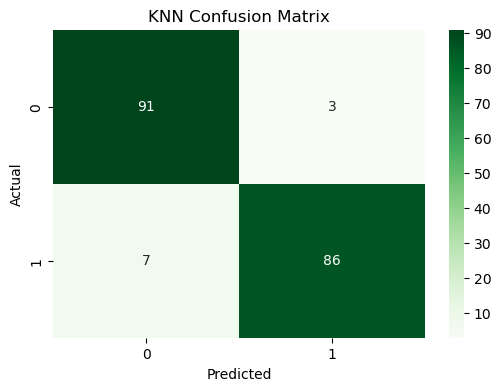

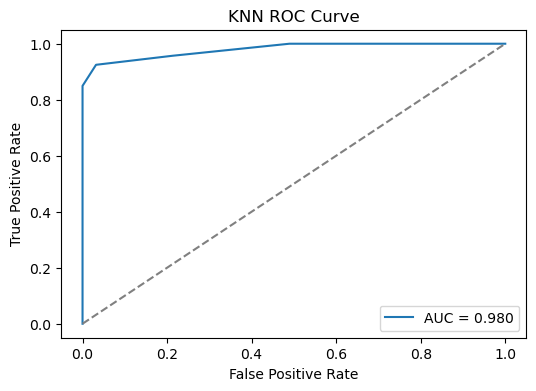

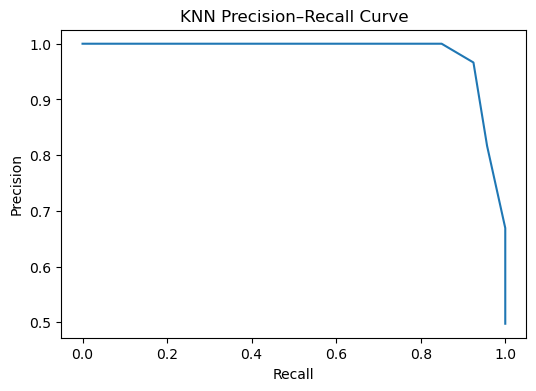


Average distance to 5 nearest neighbors: 2.5601
Lower values mean the data clusters well (good for KNN).


In [15]:
# ============================================================
#   K-NEAREST NEIGHBORS (KNN) — FULL MODEL EVALUATION
#   This cell trains the KNN model and evaluates it using:
#     ✔ Accuracy
#     ✔ Classification Report
#     ✔ Confusion Matrix
#     ✔ ROC Curve + AUC
#     ✔ Precision–Recall Curve
#     ✔ Distance-based intuition (unique to KNN)
#   Every section includes comments explaining what to look for.
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)
import numpy as np

# ------------------------------------------------------------
# 1. Train the KNN model
# ------------------------------------------------------------
# KNN relies heavily on distances between points.
# Scaling is CRITICAL — without it, features with large ranges dominate.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]  # needed for ROC/PR curves


# ------------------------------------------------------------
# 2. Accuracy Score
# ------------------------------------------------------------
# Accuracy = proportion of correct predictions.
# KNN can struggle in high-dimensional datasets.
accuracy = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy: {accuracy:.4f}")


# ------------------------------------------------------------
# 3. Classification Report
# ------------------------------------------------------------
# Shows precision, recall, and F1-score for each class.
# Look for balanced values across both classes.
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


# ------------------------------------------------------------
# 4. Confusion Matrix
# ------------------------------------------------------------
# Shows EXACTLY where the model is making mistakes.
# Diagonal = correct predictions.
# Off-diagonal = errors.
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ------------------------------------------------------------
# 5. ROC Curve + AUC Score
# ------------------------------------------------------------
# ROC curve shows how well the model separates the two classes.
# AUC close to 1.0 = excellent.
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.title("KNN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# ------------------------------------------------------------
# 6. Precision–Recall Curve
# ------------------------------------------------------------
# Useful when one class is less common.
# Look for curves that stay high (good precision)
# and far right (good recall).
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_knn)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title("KNN Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


# ------------------------------------------------------------
# 7. Distance-based intuition (unique to KNN)
# ------------------------------------------------------------
# KNN predictions depend on the distances to the nearest neighbors.
# We can inspect the average distance to the 5 nearest neighbors.
# Lower distances = tighter clusters = easier classification.
distances, indices = knn.kneighbors(X_test_scaled)

avg_distance = np.mean(distances)
print(f"\nAverage distance to 5 nearest neighbors: {avg_distance:.4f}")
print("Lower values mean the data clusters well (good for KNN).")
